In [ ]:
!pip install playsound

  Preparing metadata (setup.py) ... done
  Created wheel for playsound: filename=playsound-1.3.0-py3-none-any.whl size=7020 sha256=50394a94f5f430c229f01922bcd9e332bd48768e7aeed74b0d9480e10169fd4d
  Stored in directory: /root/.cache/pip/wheels/cf/42/ff/7c587bae55eec67b909ca316b250d9b4daedbf272a3cbeb907
Successfully built playsound


In [ ]:
import os
import re
import torch
import librosa
import torchaudio
import numpy as np
import pandas as pd
import seaborn as sns
import librosa.display
import tensorflow as tf
from itertools import cycle
from google.colab import drive
import matplotlib.pyplot as plt
from IPython.display import Audio
from sklearn.utils import class_weight
from tensorflow.keras.models import Model
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, roc_curve, auc
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Dropout, Concatenate, Resizing, Concatenate, Flatten, Embedding

In [ ]:

from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input, Embedding, Concatenate
from tensorflow.keras.models import Model, load_model



In [ ]:
# Google Drive'ı bağlama
drive.mount('/content/drive')

# Google Drive'daki klasör yolu
directory = "/content/drive/My Drive/Colab Notebooks/heart sound"

In [ ]:
# Google Drive'ı bağlama
drive.mount('/content/drive')

# Google Drive'daki klasör yolu
directory = "/content/drive/My Drive/Colab Notebooks/heart_sound"

# Dizindeki dosyaları listeleme
try:
    file_names = os.listdir(directory)
    for file_name in file_names:
        if file_name.endswith(".wav"):  # Sadece .wav dosyalarını al
            print(file_name)
            file_path = os.path.join(directory, file_name)
            print(f"Dosya yolu: {file_path}")
except FileNotFoundError:
    print(f"Hata: '{directory}' dizini bulunamadı. Lütfen doğru bir yol girin.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
F_ESM_LUA.wav
Dosya yolu: /content/drive/My Drive/Colab Notebooks/heart_sound/F_ESM_LUA.wav
M_LDM_LC.wav
Dosya yolu: /content/drive/My Drive/Colab Notebooks/heart_sound/M_LDM_LC.wav
F_S3_RC.wav
Dosya yolu: /content/drive/My Drive/Colab Notebooks/heart_sound/F_S3_RC.wav
F_AF_LLA.wav
Dosya yolu: /content/drive/My Drive/Colab Notebooks/heart_sound/F_AF_LLA.wav
M_S4_RUSB.wav
Dosya yolu: /content/drive/My Drive/Colab Notebooks/heart_sound/M_S4_RUSB.wav
M_S3_RUSB.wav
Dosya yolu: /content/drive/My Drive/Colab Notebooks/heart_sound/M_S3_RUSB.wav
M_ESM_A.wav
Dosya yolu: /content/drive/My Drive/Colab Notebooks/heart_sound/M_ESM_A.wav
F_LDM_LLSB.wav
Dosya yolu: /content/drive/My Drive/Colab Notebooks/heart_sound/F_LDM_LLSB.wav
M_AF_LC.wav
Dosya yolu: /content/drive/My Drive/Colab Notebooks/heart_sound/M_AF_LC.wav
M_T_LUSB_.wav
Dosya yolu: /content/drive/My Drive/Colab N

In [ ]:
# Etiketleri saklayacak liste
labels = []
directory = "/content/drive/My Drive/Colab Notebooks/heart_sound"

# Dizin içindeki dosyaları gez
for file_name in os.listdir(directory):
    if file_name.endswith(".wav"):  # Sadece wav dosyalarını al
        # Olası boşlukları temizle ve uzantıyı at
        clean_name = file_name.strip().replace(".wav", "")

        # Dosya adını alt çizgilere göre parçala
        # Örn: "M_S4_RUA_2" -> ["M", "S4", "RUA", "2"]
        parts = clean_name.split("_")

        # En az 3 parça (Cinsiyet, Hastalık, Konum) olduğundan emin ol
        if len(parts) >= 3:
            gender = parts[0]       # İlk parça: Cinsiyet (M/F)
            diagnosis = parts[1]    # İkinci parça: Hastalık/Ses Türü (S4, Normal vs.)
            location = parts[2]     # Üçüncü parça: Konum (RUA, Apex vs.)

            # Etiketler listesine ekle
            labels.append({
                "file_name": file_name,
                "gender": gender,
                "diagnosis": diagnosis,
                "location": location
            })
        else:
            print(f"Format hatalı, atlanıyor: {file_name}")

# İlk 5 sonucu kontrol et
for label in labels[:5]:
    print(label)

{'file_name': 'F_ESM_LUA.wav', 'gender': 'F', 'diagnosis': 'ESM', 'location': 'LUA'}
{'file_name': 'M_LDM_LC.wav', 'gender': 'M', 'diagnosis': 'LDM', 'location': 'LC'}
{'file_name': 'F_S3_RC.wav', 'gender': 'F', 'diagnosis': 'S3', 'location': 'RC'}
{'file_name': 'F_AF_LLA.wav', 'gender': 'F', 'diagnosis': 'AF', 'location': 'LLA'}
{'file_name': 'M_S4_RUSB.wav', 'gender': 'M', 'diagnosis': 'S4', 'location': 'RUSB'}


In [ ]:
len(labels)

195

In [ ]:
# 1. Adım: Etiketleri analiz etme ve sayma
try:
    # Listeyi Pandas DataFrame'ine çevir (Veri analizi ve ön işleme için en iyi yol)
    df = pd.DataFrame(labels)

    if not df.empty:
        print(f"--- Toplam Veri Sayısı: {len(df)} ---\n")

        # Hastalık Dağılımı (Sınıf Dengesi Kontrolü)
        print("1. Hastalık (Diagnosis) Dağılımı:")
        print(df['diagnosis'].value_counts())
        print("-" * 30)

        # Konum Dağılımı (Embedding için kaç farklı sınıf olduğunu görmek önemli)
        print("2. Konum (Location) Dağılımı:")
        print(df['location'].value_counts())
        print("-" * 30)

        # Cinsiyet Dağılımı
        print("3. Cinsiyet Dağılımı:")
        print(df['gender'].value_counts())
        print("-" * 30)

        # Benzersiz etiketlerin listesi (Eski kodunuzdaki mantık)
        unique_diagnoses = df['diagnosis'].unique()
        print(f"Benzersiz Hastalık Etiketleri ({len(unique_diagnoses)} adet):")
        print(unique_diagnoses)

    else:
        print("Hata: 'labels' listesi boş. Dosyalar doğru okunamamış olabilir.")

except Exception as e:
    print(f"Beklenmeyen bir hata oluştu: {e}")

# 2. Adım: Modele hazırlık için Label Encoding örneği
# (Bu kısım Embedding Learning'e giden yoldur)
from sklearn.preprocessing import LabelEncoder

# Eğer DataFrame kullandıysanız, veriyi sayılara çevirmek saniyeler sürer:
# le_loc = LabelEncoder()
# df['location_encoded'] = le_loc.fit_transform(df['location'])
# print(f"\nKonumlar sayıya çevrildi. Örnek: {df[['location', 'location_encoded']].head(3)}")

--- Toplam Veri Sayısı: 195 ---

1. Hastalık (Diagnosis) Dağılımı:
diagnosis
N      22
LSM    22
MSM    21
S3     20
LDM    19
ESM    19
AF     19
T      19
S4     18
AVB    16
Name: count, dtype: int64
------------------------------
2. Konum (Location) Dağılımı:
location
LUSB    26
A       22
LLSB    22
RUSB    20
LC      18
RC      17
LMA     13
RLA     13
LLA     12
LUA     12
RMA     11
RUA      9
Name: count, dtype: int64
------------------------------
3. Cinsiyet Dağılımı:
gender
F    99
M    96
Name: count, dtype: int64
------------------------------
Benzersiz Hastalık Etiketleri (10 adet):
['ESM' 'LDM' 'S3' 'AF' 'S4' 'T' 'MSM' 'N' 'LSM' 'AVB']


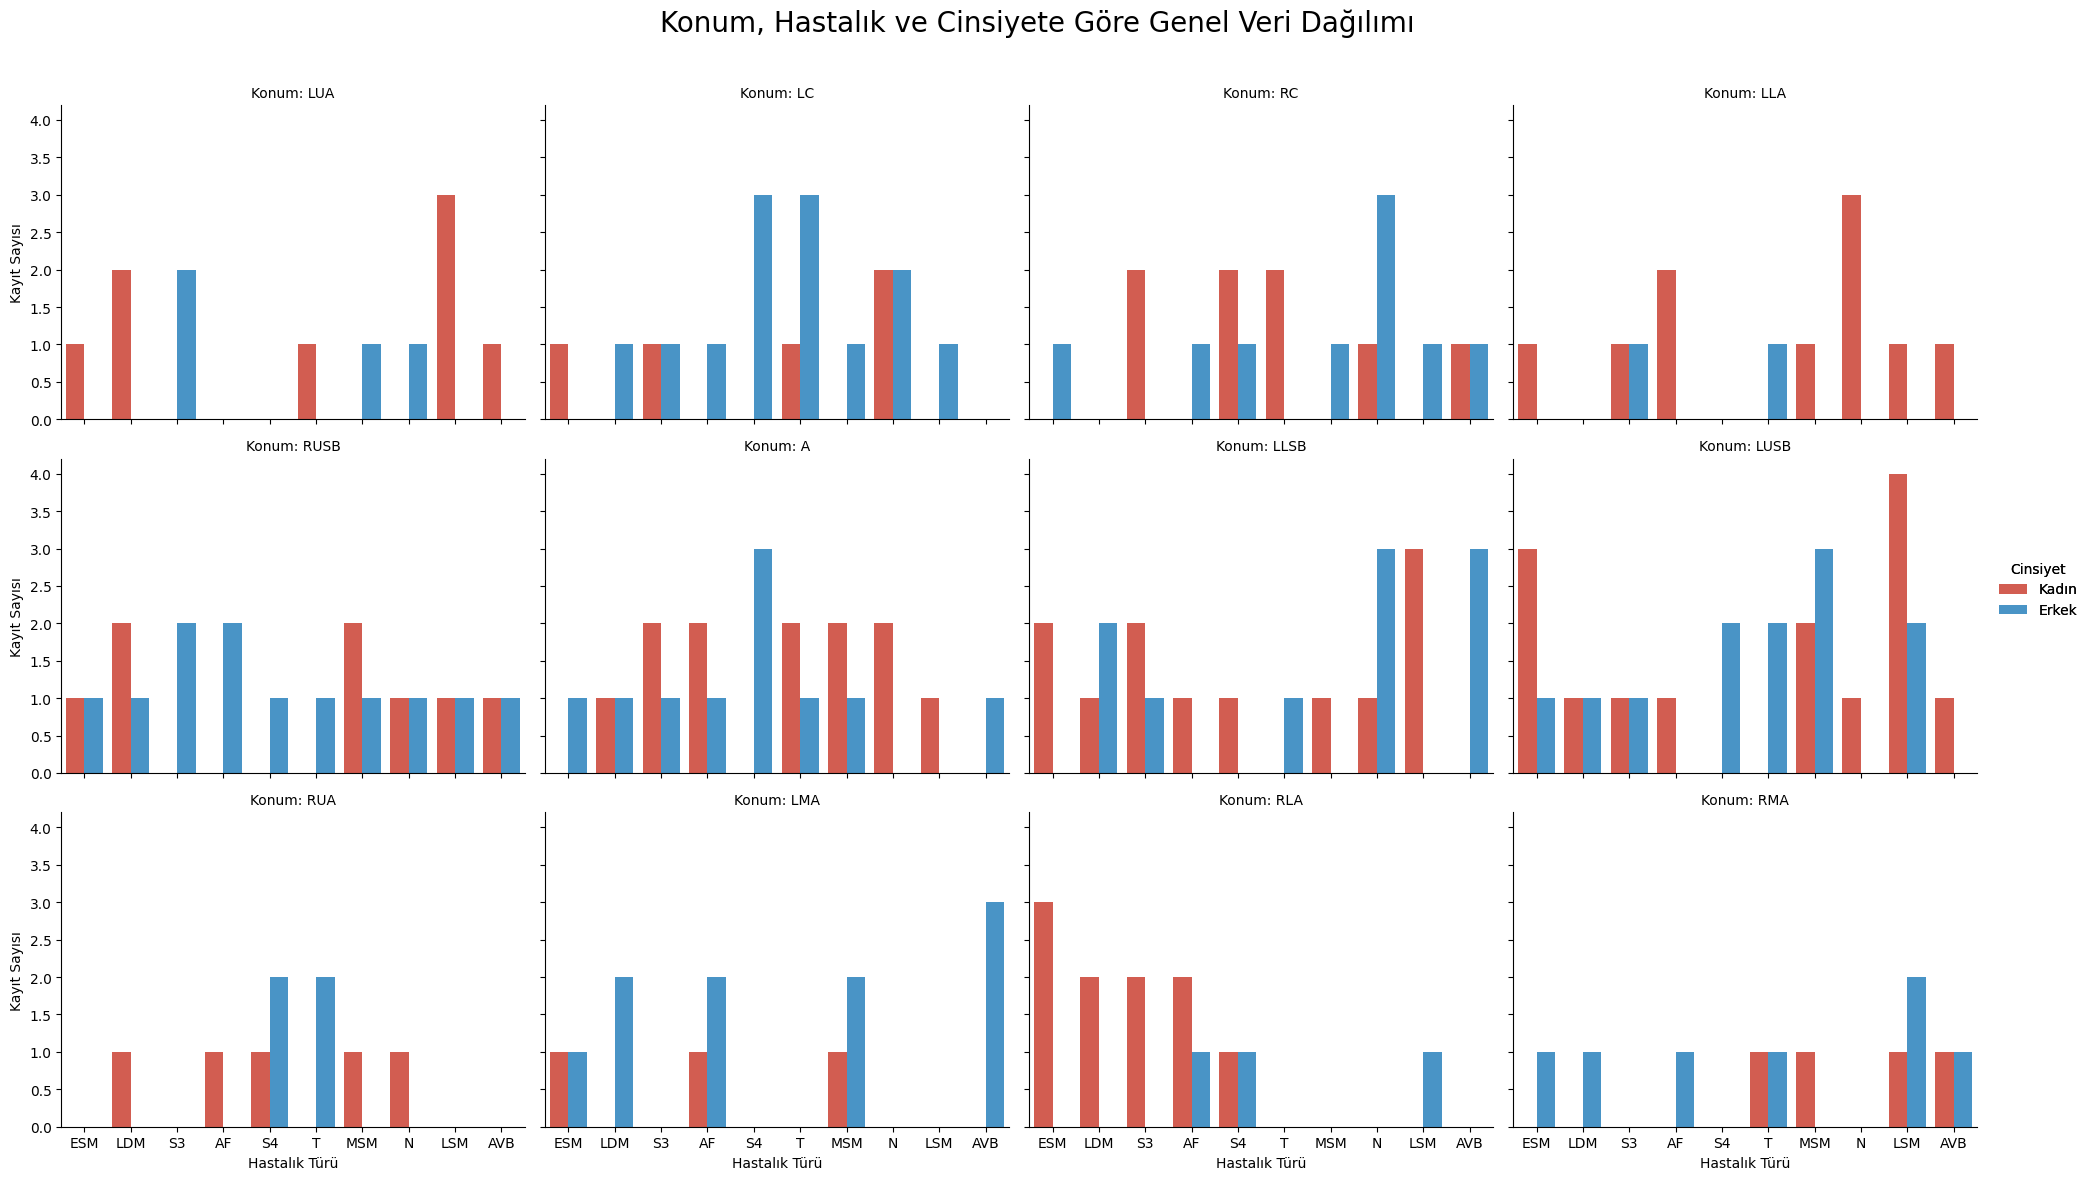

In [ ]:
# Grafiği daha anlaşılır kılmak için Cinsiyetleri Türkçeleştirelim
df['Cinsiyet'] = df['gender'].map({'M': 'Erkek', 'F': 'Kadın'})

# catplot kullanarak 3 değişkeni (Hastalık, Cinsiyet, Konum) birleştiriyoruz
g = sns.catplot(
    data=df,
    x='diagnosis',     # X ekseni: Hastalıklar
    hue='Cinsiyet',    # Renkler: Cinsiyet
    col='location',    # Sütunlar: Konumlar (Her konum için ayrı grafik)
    kind='count',
    col_wrap=4,        # Her satırda 4 grafik göster
    palette={'Erkek': '#3498db', 'Kadın': '#e74c3c'},
    height=4,
    aspect=1.2
)

# Estetik düzenlemeler
g.set_axis_labels("Hastalık Türü", "Kayıt Sayısı")
g.set_titles("Konum: {col_name}")
g.add_legend(title="Cinsiyet")

plt.subplots_adjust(top=0.9)
g.fig.suptitle('Konum, Hastalık ve Cinsiyete Göre Genel Veri Dağılımı', fontsize=20)

plt.show()

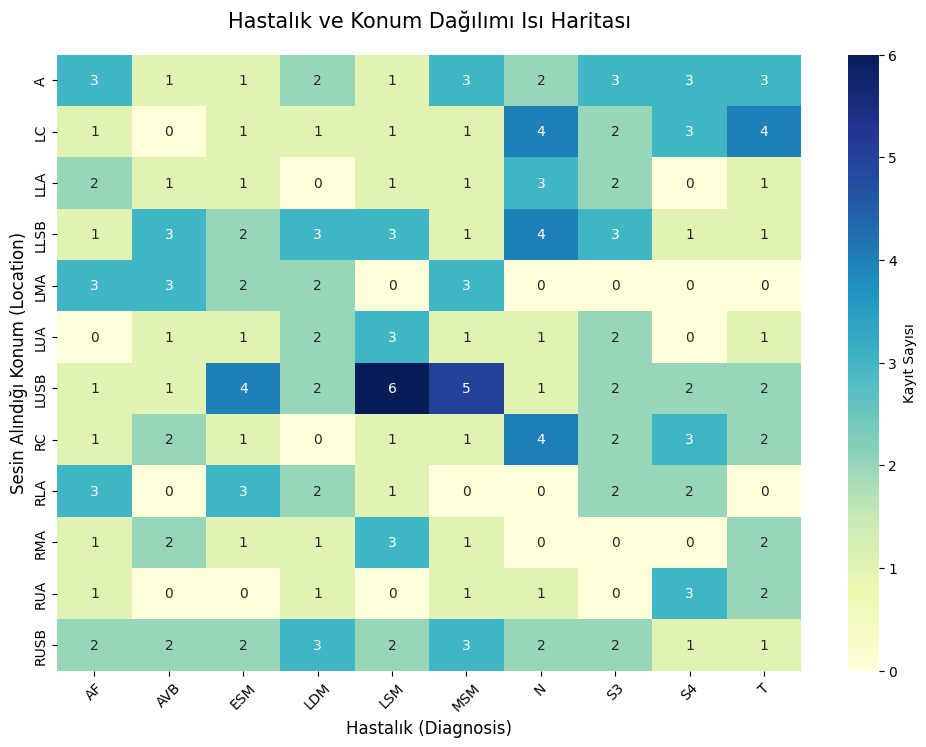

In [ ]:
# 1. Veriyi bir çapraz tabloya (Pivot Table) dönüştürelim
# Satırlarda Konum, Sütunlarda Hastalık olsun, hücrelerde ise kayıt sayısı
heatmap_data = pd.crosstab(df['location'], df['diagnosis'])

# 2. Isı Haritasını Çizelim
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu", fmt='d', cbar_kws={'label': 'Kayıt Sayısı'})

plt.title('Hastalık ve Konum Dağılımı Isı Haritası', fontsize=15, pad=20)
plt.xlabel('Hastalık (Diagnosis)', fontsize=12)
plt.ylabel('Sesin Alındığı Konum (Location)', fontsize=12)
plt.xticks(rotation=45)
plt.show()

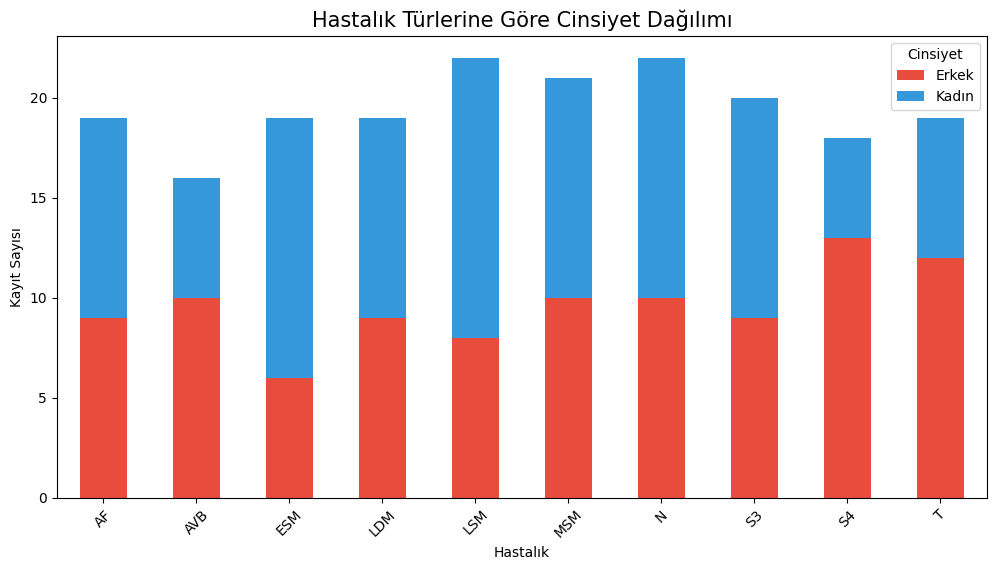

In [ ]:
# Her hastalık için erkek/kadın dağılımını gösteren yığınlı grafik
plt.figure(figsize=(12, 6))
df.groupby(['diagnosis', 'Cinsiyet']).size().unstack().plot(kind='bar', stacked=True,
                                                           color=['#e74c3c', '#3498db'],
                                                           ax=plt.gca())

plt.title('Hastalık Türlerine Göre Cinsiyet Dağılımı', fontsize=15)
plt.xlabel('Hastalık')
plt.ylabel('Kayıt Sayısı')
plt.legend(title='Cinsiyet')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Hastalıklar için (10 Sınıf)
le_diagnosis = LabelEncoder()
y_encoded = le_diagnosis.fit_transform(df['diagnosis'])
y_categorical = to_categorical(y_encoded) # One-hot encoding

# Konumlar için (12 Sınıf) - Embedding'e girecek
le_location = LabelEncoder()
location_encoded = le_location.fit_transform(df['location'])

# Cinsiyet için (2 Sınıf) - Embedding'e girecek
le_gender = LabelEncoder()
gender_encoded = le_gender.fit_transform(df['gender'])

--- Ses Dosyası Analizi: F_ESM_LUA.wav ---
Örnekleme Hızı (Sampling Rate): 4000 Hz
Süre: 15.00 saniye
Toplam Örnek Sayısı: 60000
Maksimum Genlik: 0.0972


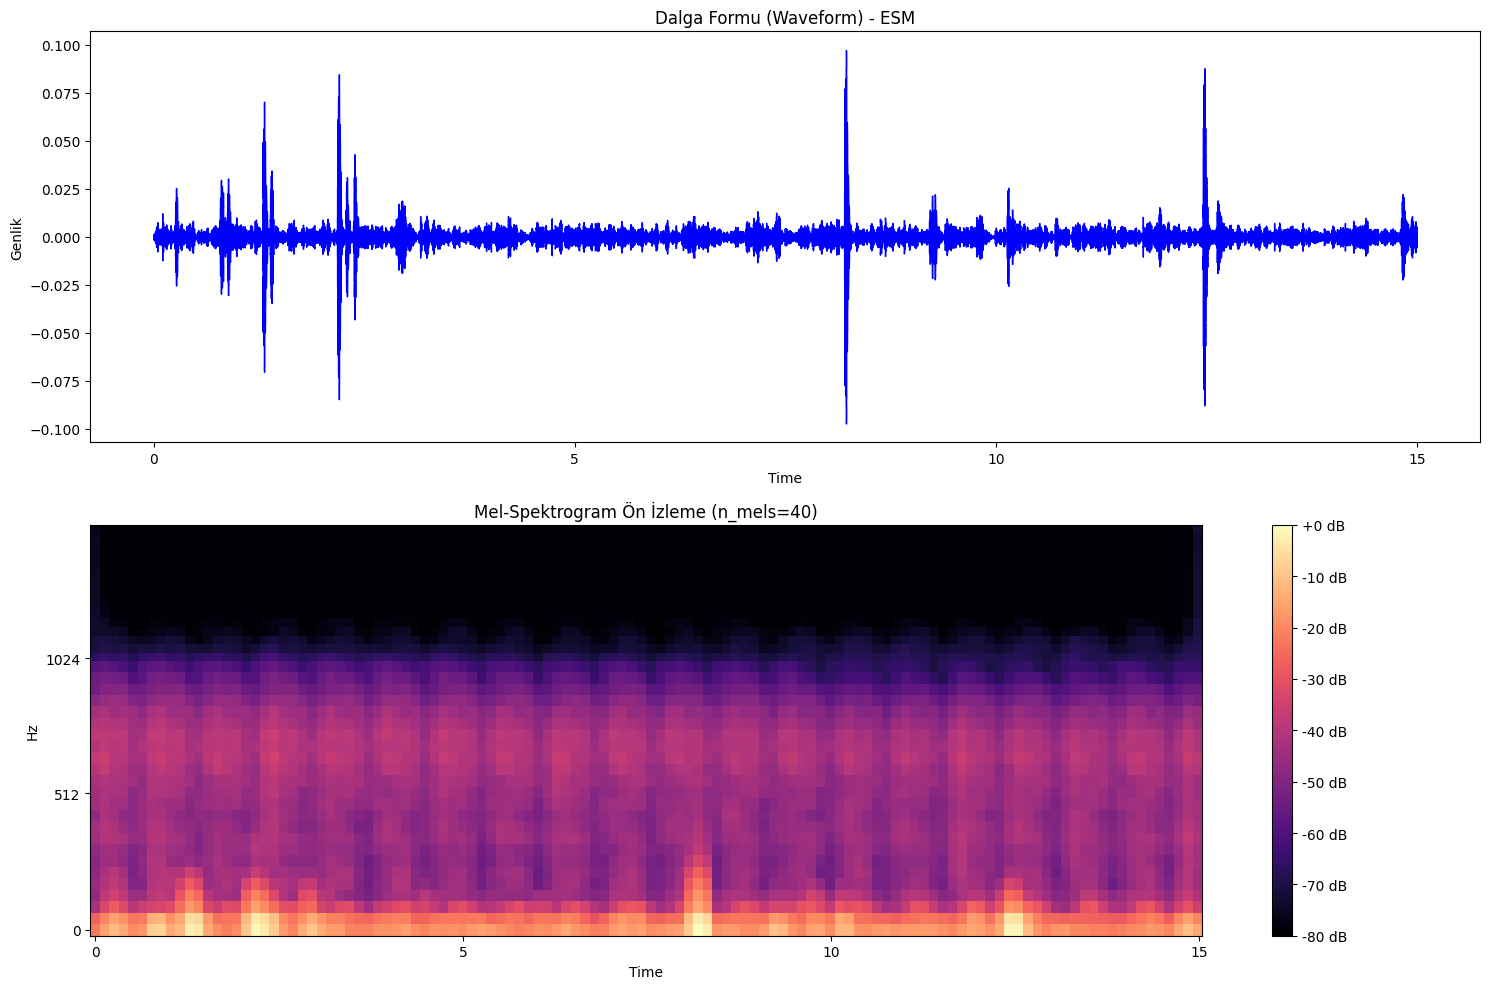

In [ ]:
# Örnek bir dosya seçelim (labels listesindeki ilk dosyayı alıyoruz)
sample_file_name = labels[0]['file_name']
# directory değişkeninin tanımlı olduğundan emin olun (örn: directory = 'sesler/')
sample_path = os.path.join(directory, sample_file_name)

# 1. Sesi yükleyelim (sr=None orijinal örnekleme hızını korur)
y, sr = librosa.load(sample_path, sr=None)

# 2. Temel Bilgileri Yazdıralım
duration = librosa.get_duration(y=y, sr=sr)
print(f"--- Ses Dosyası Analizi: {sample_file_name} ---")
print(f"Örnekleme Hızı (Sampling Rate): {sr} Hz")
print(f"Süre: {duration:.2f} saniye")
print(f"Toplam Örnek Sayısı: {len(y)}")
print(f"Maksimum Genlik: {np.max(np.abs(y)):.4f}")

# 3. Görselleştirme
plt.figure(figsize=(15, 10))

# Dalga Formu (Waveform)
plt.subplot(2, 1, 1)
librosa.display.waveshow(y, sr=sr, color='blue')
plt.title(f"Dalga Formu (Waveform) - {labels[0]['diagnosis']}")
plt.ylabel("Genlik")

# Mel-Spektrogram (Ön İzleme)
plt.subplot(2, 1, 2)
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=40) # Sizin modelle uyumlu 40 kanal
S_DB = librosa.power_to_db(S, ref=np.max)
librosa.display.specshow(S_DB, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title("Mel-Spektrogram Ön İzleme (n_mels=40)")

plt.tight_layout()
plt.show()

In [ ]:
def prepare_spectrograms(labels_list, directory_path, target_sr=22050, duration=15, n_mels=40):
    """
    Tüm ses dosyalarını gezer, spektrograma dönüştürür ve bir dizi (array) olarak döndürür.
    """
    X_audio = []

    # 15 saniyelik hedeflenen örnek sayısı
    target_samples = target_sr * duration

    print(f"{len(labels_list)} dosya işleniyor, lütfen bekleyin...")

    for entry in labels_list:
        file_path = os.path.join(directory_path, entry['file_name'])

        try:
            # 1. Sesi yükle
            y, sr = librosa.load(file_path, sr=target_sr)

            # 2. Süreyi 15 saniyeye sabitle (Padding veya Clipping)
            if len(y) > target_samples:
                y = y[:target_samples]
            else:
                y = np.pad(y, (0, target_samples - len(y)))

            # 3. Mel-Spektrogram oluştur (40 kanal)
            mel_spec = librosa.feature.melspectrogram(y=y, sr=target_sr, n_mels=n_mels)

            # 4. Logaritmik ölçeğe çevir (DB) - Modelin desenleri görmesi için şart
            mel_db = librosa.power_to_db(mel_spec, ref=np.max)

            # 5. Listeye ekle (Boyutu: 40 x Genişlik)
            X_audio.append(mel_db)

        except Exception as e:
            print(f"Hata! {entry['file_name']} dosyası işlenemedi: {e}")

    # Numpy dizisine çevir ve kanal boyutunu ekle (CNN için 1 kanal ekliyoruz)
    X_audio = np.array(X_audio)
    X_audio = X_audio[..., np.newaxis]

    return X_audio

# --- KULLANIM ---
# directory = "/content/sesler"  # Kendi yolunu yaz
X_audio_data = prepare_spectrograms(labels, directory)

print("\nDönüştürme Tamamlandı!")
print(f"Veri Seti Şekli (Adet, Yükseklik, Genişlik, Kanal): {X_audio_data.shape}")

195 dosya işleniyor, lütfen bekleyin...

Dönüştürme Tamamlandı!
Veri Seti Şekli (Adet, Yükseklik, Genişlik, Kanal): (195, 40, 646, 1)


In [ ]:
# 1. Verileri bir DataFrame'e koyalım (Eğer daha önce yapmadıysanız)
df = pd.DataFrame(labels)

# 2. Hastalık Etiketlerini (Y) Sayıya Çevirelim
le_diag = LabelEncoder()
y_encoded = le_diag.fit_transform(df['diagnosis'])
y_categorical = to_categorical(y_encoded)

# 3. Konum Bilgisini (X2) Sayıya Çevirelim (Embedding için)
le_loc = LabelEncoder()
X_loc_encoded = le_loc.fit_transform(df['location'])

# 4. Veriyi Bölüyoruz (Eğitim %80, Test %20)
# Hem Sesi hem de Konumu aynı anda bölüyoruz ki eşleşme bozulmasun
X_audio_train, X_audio_test, X_loc_train, X_loc_test, y_train, y_test = train_test_split(
    X_audio_data,        # Ses veriniz (195, 40, 646, 1)
    X_loc_encoded,       # Konum veriniz (195,)
    y_categorical,       # Hedef etiketler (195, 10)
    test_size=0.2,
    random_state=42,
    stratify=y_encoded   # Her hastalıktan dengeli bölmek için çok önemli!
)

print(f"Eğitim seti: {X_audio_train.shape[0]} örnek")
print(f"Test seti: {X_audio_test.shape[0]} örnek")

Eğitim seti: 156 örnek
Test seti: 39 örnek


In [ ]:
import os
import numpy as np

# 1. Ana dizin yolunu tanımla
base_path = "/content/drive/My Drive/Colab Notebooks/heart sound/"
data_path = os.path.join(base_path, "processed_data/")

# 2. Klasörü oluştur (Eğer zaten varsa hata vermez)
os.makedirs(data_path, exist_ok=True)

# 3. Verileri .npy formatında bu yeni klasöre kaydet
np.save(data_path + 'X_audio_train.npy', X_audio_train)
np.save(data_path + 'X_audio_test.npy', X_audio_test)
np.save(data_path + 'X_loc_train.npy', X_loc_train)
np.save(data_path + 'X_loc_test.npy', X_loc_test)
np.save(data_path + 'y_train.npy', y_train)
np.save(data_path + 'y_test.npy', y_test)

print(f"✅ İşlenmiş veriler başarıyla şu adrese kaydedildi:\n{data_path}")

✅ İşlenmiş veriler başarıyla şu adrese kaydedildi:
/content/drive/My Drive/Colab Notebooks/heart sound/processed_data/


In [ ]:
# 1. Etiketleri Sayısallaştıralım
# labels listesini DataFrame'e çevirdiğinizi varsayıyorum
df = pd.DataFrame(labels)

# Hastalıklar (Y) - 10 Sınıf
le_diag = LabelEncoder()
y_encoded = le_diag.fit_transform(df['diagnosis'])
y_categorical = to_categorical(y_encoded)

# Konumlar (X_loc) - 12 Sınıf
le_loc = LabelEncoder()
X_loc_encoded = le_loc.fit_transform(df['location'])

# 2. Eğitim ve Test Setine Bölme (%80 - %20)
# X_audio_data: (195, 40, 646, 1) olan diziniz
X_train_audio, X_test_audio, X_train_loc, X_test_loc, y_train, y_test = train_test_split(
    X_audio_data,
    X_loc_encoded,
    y_categorical,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded # Sınıf dengesi için kritik
)

print(f"Eğitim: {len(X_train_audio)} | Test: {len(X_test_audio)}")

Eğitim: 156 | Test: 39


# Embeding Learning CNN + Konum iki kollu

In [ ]:
# --- KOL 1: SES (CNN) ---
audio_input = Input(shape=(40, 646, 1), name='audio_input')
x = Conv2D(32, (3, 3), activation='relu', padding='same')(audio_input)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2))(x)
x = Flatten()(x)
audio_features = Dense(128, activation='relu')(x)

# --- KOL 2: KONUM (EMBEDDING) ---
loc_input = Input(shape=(1,), name='loc_input')
# 12 konum + 1 (emniyet payı), her konumu 4 boyutlu bir vektöre eşle
loc_emb = Embedding(input_dim=len(le_loc.classes_) + 1, output_dim=4)(loc_input)
loc_features = Flatten()(loc_emb)

# --- BİRLEŞTİRME VE ÇIKIŞ ---
combined = Concatenate()([audio_features, loc_features])
z = Dense(64, activation='relu')(combined)
z = Dropout(0.5)(z)
output = Dense(len(le_diag.classes_), activation='softmax')(z)

# MODELİ OLUŞTUR
model = Model(inputs=[audio_input, loc_input], outputs=output)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ audio_input         │ (None, 40, 646,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 40, 646,   │        320 │ audio_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 20, 323,   │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 20, 323,   │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 10, 161,   │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ loc_input           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 103040)    │          0 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 4)      │         52 │ loc_input[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │ 13,189,248 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 4)         │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 132)       │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,512 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 10)        │        650 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 13,217,278 (50.42 MB)

 Trainable params: 13,217,278 (50.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 789ms/step - accuracy: 0.1411 - loss: 297.7576 - val_accuracy: 0.1026 - val_loss: 8.6112
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 708ms/step - accuracy: 0.1295 - loss: 6.1498 - val_accuracy: 0.1026 - val_loss: 2.2958
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 943ms/step - accuracy: 0.1688 - loss: 2.2925 - val_accuracy: 0.1795 - val_loss: 2.2794
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 906ms/step - accuracy: 0.1962 - loss: 2.3098 - val_accuracy: 0.1026 - val_loss: 2.2772
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 706ms/step - accuracy: 0.3172 - loss: 2.2432 - val_accuracy: 0.2564 - val_loss: 2.1896
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 930ms/step - accuracy: 0.3147 - loss: 2.0706 - val_accuracy: 0.2564 - val_loss: 2.0806
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 753ms/step - accuracy: 0.3688 - loss: 1.9119 - val_accuracy: 0.3077 - val_loss: 2.0975
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.4762 - loss: 1.6346 - val_accuracy:

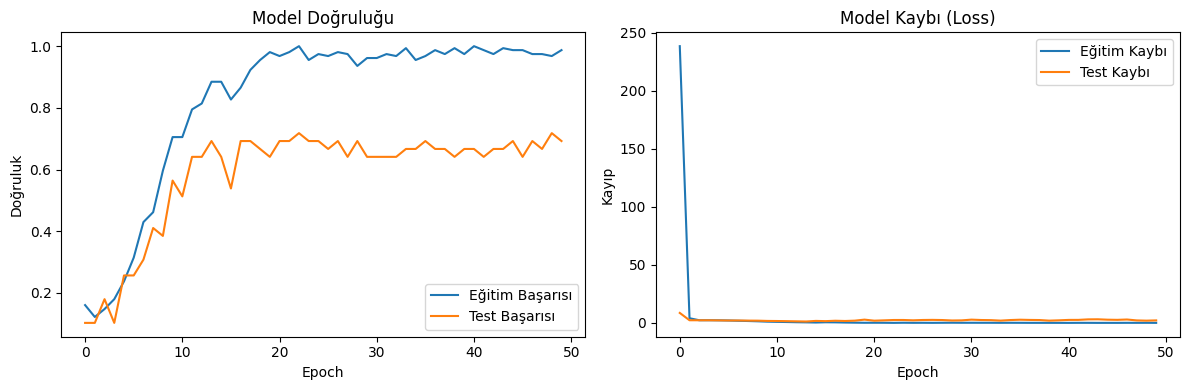

In [ ]:
# 1. Modeli Eğitme
# Not: epochs sayısını 50-100 arası tutabilirsin
history = model.fit(
    x=[X_train_audio, X_train_loc],
    y=y_train,
    validation_data=([X_test_audio, X_test_loc], y_test),
    epochs=50,
    batch_size=16,
    verbose=1
)

# 2. Eğitim Sürecini Görselleştirme (Accuracy ve Loss Grafikleri)
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Doğruluk (Accuracy) Grafiği
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Eğitim Başarısı')
plt.plot(history.history['val_accuracy'], label='Test Başarısı')
plt.title('Model Doğruluğu')
plt.xlabel('Epoch')
plt.ylabel('Doğruluk')
plt.legend()

# Kayıp (Loss) Grafiği
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Eğitim Kaybı')
plt.plot(history.history['val_loss'], label='Test Kaybı')
plt.title('Model Kaybı (Loss)')
plt.xlabel('Epoch')
plt.ylabel('Kayıp')
plt.legend()

plt.tight_layout()
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step


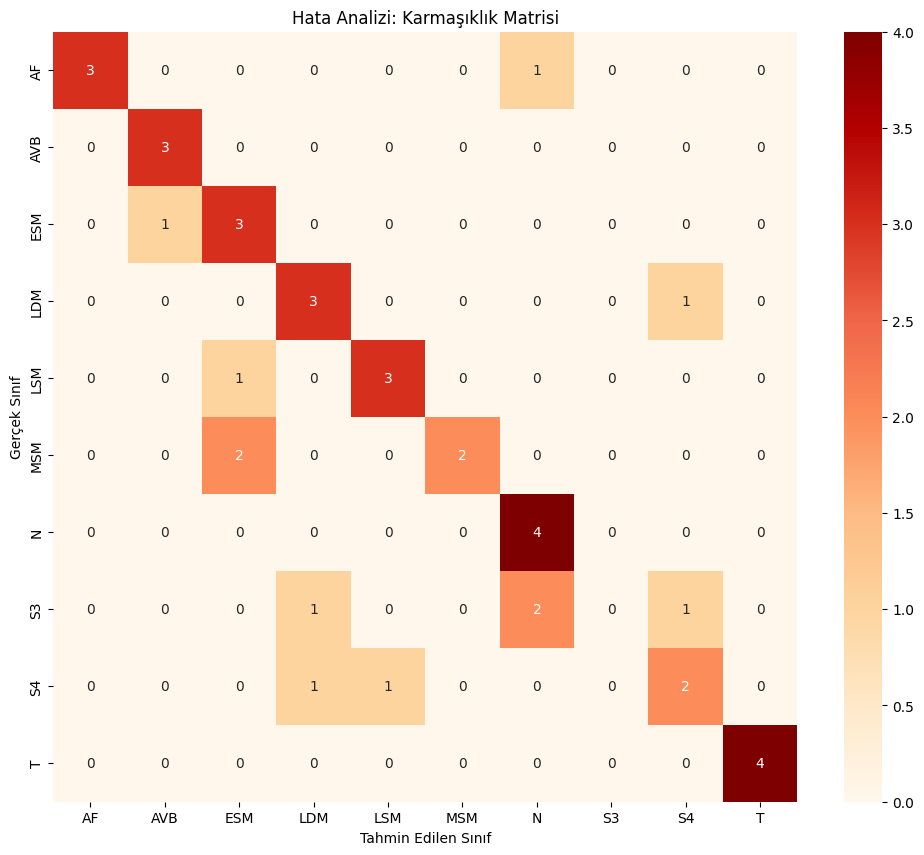


--- Sınıflandırma Raporu ---
              precision    recall  f1-score   support

          AF       1.00      0.75      0.86         4
         AVB       0.75      1.00      0.86         3
         ESM       0.50      0.75      0.60         4
         LDM       0.60      0.75      0.67         4
         LSM       0.75      0.75      0.75         4
         MSM       1.00      0.50      0.67         4
           N       0.57      1.00      0.73         4
          S3       0.00      0.00      0.00         4
          S4       0.50      0.50      0.50         4
           T       1.00      1.00      1.00         4

    accuracy                           0.69        39
   macro avg       0.67      0.70      0.66        39
weighted avg       0.67      0.69      0.66        39


Ortalama ROC-AUC Skoru: 0.9121


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


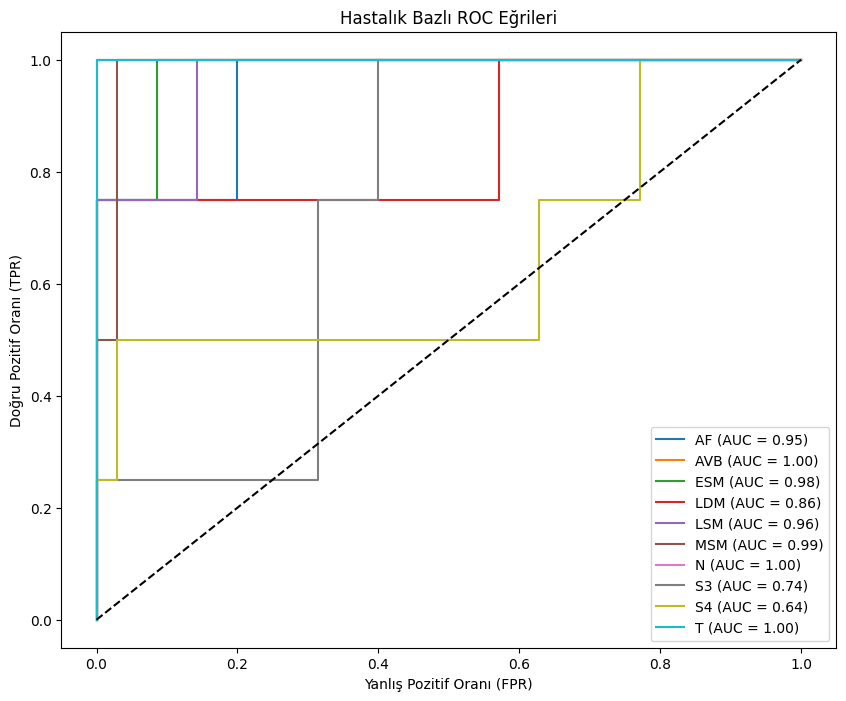

In [ ]:
# 1. Tahminleri alalım
y_pred_prob = model.predict([X_test_audio, X_test_loc])
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

# --- A. Karmaşıklık Matrisi ---
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='OrRd',
            xticklabels=le_diag.classes_,
            yticklabels=le_diag.classes_)
plt.title('Hata Analizi: Karmaşıklık Matrisi')
plt.ylabel('Gerçek Sınıf')
plt.xlabel('Tahmin Edilen Sınıf')
plt.show()

# --- B. Sınıflandırma Raporu ---
print("\n--- Sınıflandırma Raporu ---")
print(classification_report(y_true, y_pred, target_names=le_diag.classes_))

# --- C. ROC-AUC Skoru ve Eğrisi ---
# Çok sınıflı ROC-AUC (One-vs-Rest)
roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')
print(f"\nOrtalama ROC-AUC Skoru: {roc_auc:.4f}")

# ROC Eğrisini Çizdirelim
plt.figure(figsize=(10, 8))
for i in range(len(le_diag.classes_)):
    fpr, tpr, _ = roc_curve(y_test[:, i], y_pred_prob[:, i])
    plt.plot(fpr, tpr, label=f'{le_diag.classes_[i]} (AUC = {roc_auc_score(y_test[:, i], y_pred_prob[:, i]):.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Yanlış Pozitif Oranı (FPR)')
plt.ylabel('Doğru Pozitif Oranı (TPR)')
plt.title('Hastalık Bazlı ROC Eğrileri')
plt.legend(loc='lower right')
plt.show()

Rapor Analizi ve Kritik Bulgular
S3 Sınıfı Tamamen Kayıp (F1-score: 0.00): Model S3 (3. kalp sesi) sınıfından hiçbir örneği doğru tahmin edememiş. Bu sesler muhtemelen çok düşük frekanslı ve modelin şu anki CNN katmanları bu ince farkı ayırt edemiyor.

Karışıklık Bölgeleri (MSM ve S4): MSM (Mid-systolic murmur) ve S4 sesleri %44 F1-skoru ile oldukça düşük kalmış. Precision ve Recall değerlerine bakılırsa, model bu sesleri birbirine veya "Normal (N)" sınıfa karıştırıyor olabilir.

Başarı Hikayeleri (AF, LDM, LSM): Liner ve Systolic üfürümlerde (LDM, LSM) başarı yüksek. Bu, modelin "üfürüm" dokusunu genel olarak anladığını ancak spesifik sesleri (S3-S4 gibi) ayırmakta zorlandığını gösteriyor.

Dengesi Bozukluk (Precision vs. Recall): "Normal (N)" ve "T (Tachycardia)" sınıflarında Recall 1.00 ama Precision düşük. Yani model "Emin değilsem 'Normal' diyeyim" stratejisine kaçmış. Bu, küçük veri setlerindeki tipik bir "güvenli liman" davranışıdır.

ROC-AUC skorunun 0.9127 olması aslında çok umut verici! Bu rakam bize şunu söyler: Modelin sınıfları birbirinden ayırt etme potansiyeli çok yüksek, ancak "karar verme" (threshold) ve "ezberleme" (overfitting) aşamasında sınıfta kalıyor.

In [ ]:
# 1. Eğitim setindeki sayısal etiketleri al (One-hot olmayan hali)
y_train_integers = np.argmax(y_train, axis=1)

# 2. Sınıf ağırlıklarını 'balanced' (dengeli) modda hesapla
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_integers),
    y=y_train_integers
)

# 3. Keras'ın anlayacağı sözlük formatına çevir
class_weights_dict = dict(enumerate(weights))

print("Hesaplanan Sınıf Ağırlıkları:", class_weights_dict)

Hesaplanan Sınıf Ağırlıkları: {0: np.float64(1.04), 1: np.float64(1.2), 2: np.float64(1.04), 3: np.float64(1.04), 4: np.float64(0.8666666666666667), 5: np.float64(0.9176470588235294), 6: np.float64(0.8666666666666667), 7: np.float64(0.975), 8: np.float64(1.1142857142857143), 9: np.float64(1.04)}


# MobileNetV2

In [ ]:
# --- 1. SES KOLU (TRANSFER LEARNING) ---
audio_input = Input(shape=(40, 646, 1), name='audio_input')

# MobileNet 3 kanal (RGB) ve belirli boyut ister
x = Concatenate()([audio_input, audio_input, audio_input])
x = Resizing(224, 224)(x)

# MobileNetV2 Gövdesi (Ağırlıklar donduruldu)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=x)
base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
audio_features = Dense(256, activation='relu')(x)
audio_features = Dropout(0.4)(audio_features)

# --- 2. KONUM KOLU (EMBEDDING) ---
loc_input = Input(shape=(1,), name='loc_input')
loc_emb = Embedding(input_dim=len(le_loc.classes_) + 1, output_dim=8)(loc_input)
loc_features = Flatten()(loc_emb)

# --- BİRLEŞTİRME ---
combined = Concatenate()([audio_features, loc_features])
z = Dense(64, activation='relu')(combined)
z = Dropout(0.5)(z)
output = Dense(len(le_diag.classes_), activation='softmax')(z)

transfer_model = Model(inputs=[audio_input, loc_input], outputs=output)
transfer_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), # Daha düşük öğrenme hızı
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

# --- ERKEN DURDURMA (Overfitting'i keser) ---
early_stop = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)

# EĞİTİM
history_tl = transfer_model.fit(
    x=[X_train_audio, X_train_loc],
    y=y_train,
    validation_data=([X_test_audio, X_test_loc], y_test),
    epochs=100,
    batch_size=16,
    class_weight=class_weights_dict,
    callbacks=[early_stop],
    verbose=1
)

/tmp/ipython-input-3006603983.py:9: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=x)


Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.0604 - loss: 2.6589 - val_accuracy: 0.1282 - val_loss: 2.2153
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 930ms/step - accuracy: 0.1249 - loss: 2.2608 - val_accuracy: 0.2821 - val_loss: 2.1805
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 714ms/step - accuracy: 0.1358 - loss: 2.2252 - val_accuracy: 0.2564 - val_loss: 2.1804
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.1779 - loss: 2.1684 - val_accuracy: 0.3077 - val_loss: 2.1504
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 892ms/step - accuracy: 0.2341 - loss: 2.1821 - val_accuracy: 0.3077 - val_loss: 2.1302
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.1838 - loss: 2.2274 - val_accuracy: 0.3077 - val_loss: 2.0688
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 966ms/step - accuracy: 0.2164 - loss: 2.1584 - val_accuracy: 0.3590 - val_loss: 2.0131
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 923ms/step - accuracy: 0.2469 - loss: 2.1608 - val_accuracy:

sonradan çalıştırdığım modelin sonucu

2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step

🎯 MOBILENETV2 MULTI-INPUT MODEL SONUÇLARI
📊 Genel Test Doğruluğu (Accuracy):      %76.92
⚖️  Dengelenmiş Doğruluk (Balanced Acc): %77.50

📋 Sınıf Bazlı Detaylı Rapor (Precision, Recall, F1):

              precision    recall  f1-score   support

          AF       0.60      0.75      0.67         4
         AVB       1.00      1.00      1.00         3
         ESM       0.75      0.75      0.75         4
         LDM       1.00      1.00      1.00         4
         LSM       0.75      0.75      0.75         4
         MSM       0.75      0.75      0.75         4
           N       0.60      0.75      0.67         4
          S3       1.00      0.25      0.40         4
          S4       0.60      0.75      0.67         4
           T       1.00      1.00      1.00         4

    accuracy                           0.77        39
   macro avg       0.81      0.78      0.76        39
weighted avg       0.80      0.77      0.76        39



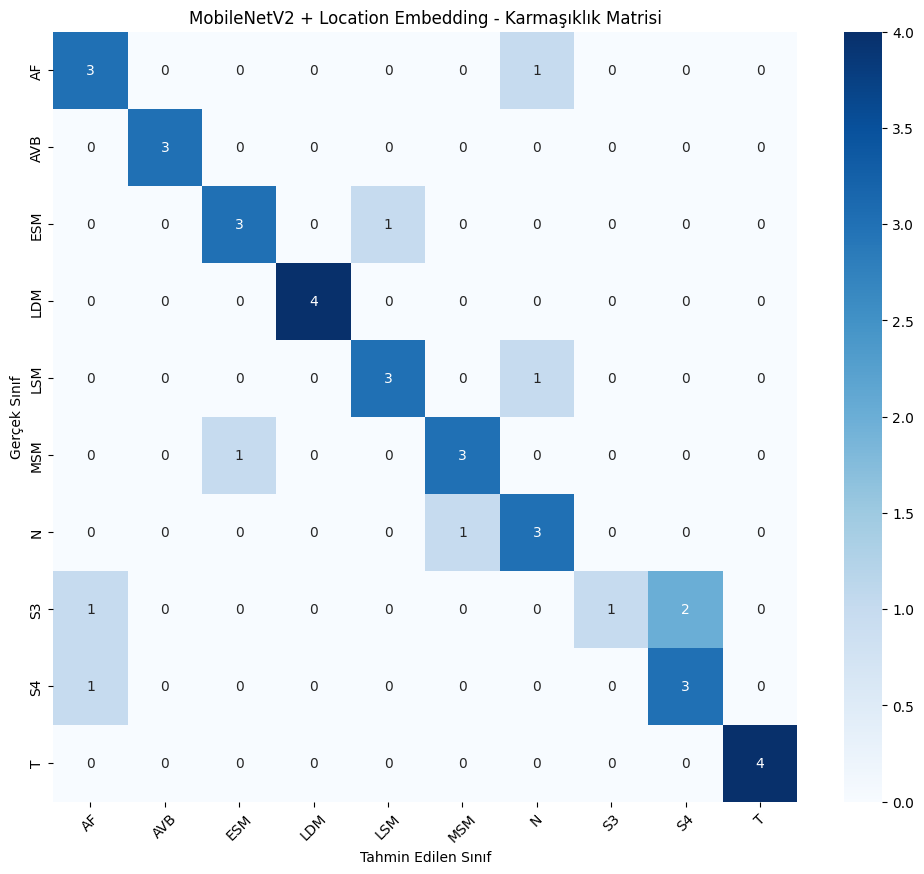

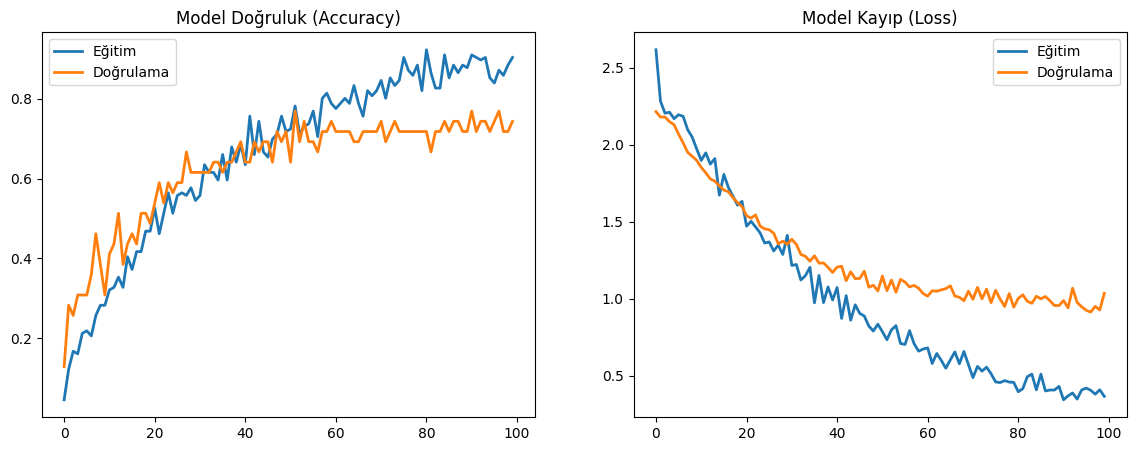

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, balanced_accuracy_score, confusion_matrix

# 1. Tahminleri Al (Multi-Input yapısına uygun olarak)
# Test verilerini modele liste olarak veriyoruz: [Ses_Verisi, Konum_Verisi]
y_pred_probs = transfer_model.predict([X_test_audio, X_test_loc])
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# 2. Temel Başarı Metrikleri
genel_acc = accuracy_score(y_true, y_pred)
balanced_acc = balanced_accuracy_score(y_true, y_pred)

print("\n" + "="*60)
print("🎯 MOBILENETV2 MULTI-INPUT MODEL SONUÇLARI")
print("="*60)
print(f"📊 Genel Test Doğruluğu (Accuracy):      %{genel_acc*100:.2f}")
print(f"⚖️  Dengelenmiş Doğruluk (Balanced Acc): %{balanced_acc*100:.2f}")
print("="*60)

# 3. Detaylı Sınıflandırma Raporu
# Sınıf isimlerini 'le_diag.classes_' üzerinden otomatik alıyoruz
class_names = list(le_diag.classes_)
print("\n📋 Sınıf Bazlı Detaylı Rapor (Precision, Recall, F1):\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# 4. Karmaşıklık Matrisi (Confusion Matrix)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('MobileNetV2 + Location Embedding - Karmaşıklık Matrisi')
plt.xlabel('Tahmin Edilen Sınıf')
plt.ylabel('Gerçek Sınıf')
plt.xticks(rotation=45)
plt.show()

# 5. Eğitim Süreci Grafikleri (Loss & Accuracy)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_tl.history['accuracy'], label='Eğitim', lw=2)
plt.plot(history_tl.history['val_accuracy'], label='Doğrulama', lw=2)
plt.title('Model Doğruluk (Accuracy)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_tl.history['loss'], label='Eğitim', lw=2)
plt.plot(history_tl.history['val_loss'], label='Doğrulama', lw=2)
plt.title('Model Kayıp (Loss)')
plt.legend()
plt.show()

In [ ]:
# Tahminleri al ve raporla
y_pred = transfer_model.predict([X_test_audio, X_test_loc])
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred_classes, target_names=le_diag.classes_))

2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step
              precision    recall  f1-score   support

          AF       0.75      0.75      0.75         4
         AVB       0.75      1.00      0.86         3
         ESM       0.75      0.75      0.75         4
         LDM       1.00      1.00      1.00         4
         LSM       0.75      0.75      0.75         4
         MSM       1.00      0.75      0.86         4
           N       0.60      0.75      0.67         4
          S3       1.00      0.25      0.40         4
          S4       0.50      0.75      0.60         4
           T       1.00      1.00      1.00         4

    accuracy                           0.77        39
   macro avg       0.81      0.78      0.76        39
weighted avg       0.81      0.77      0.76        39



2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 532ms/step


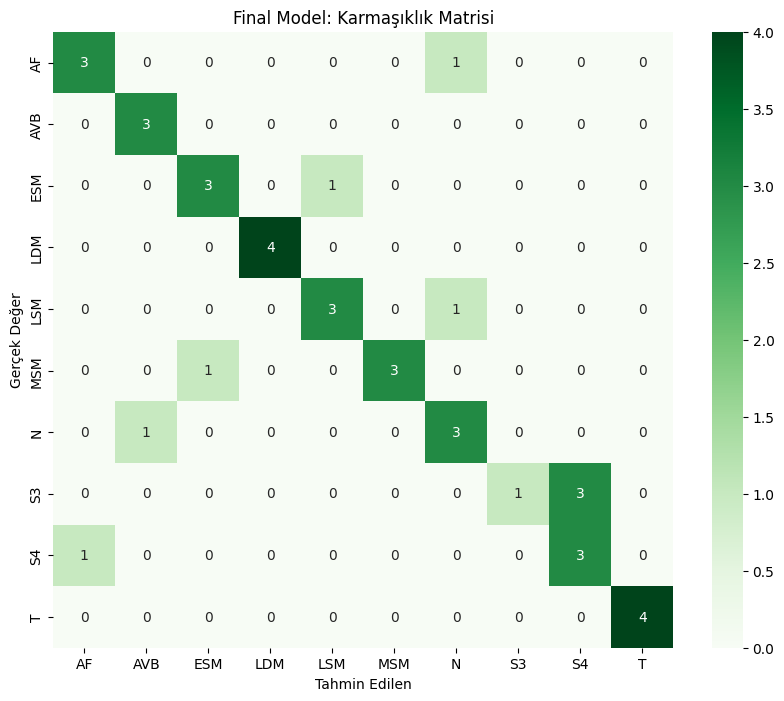

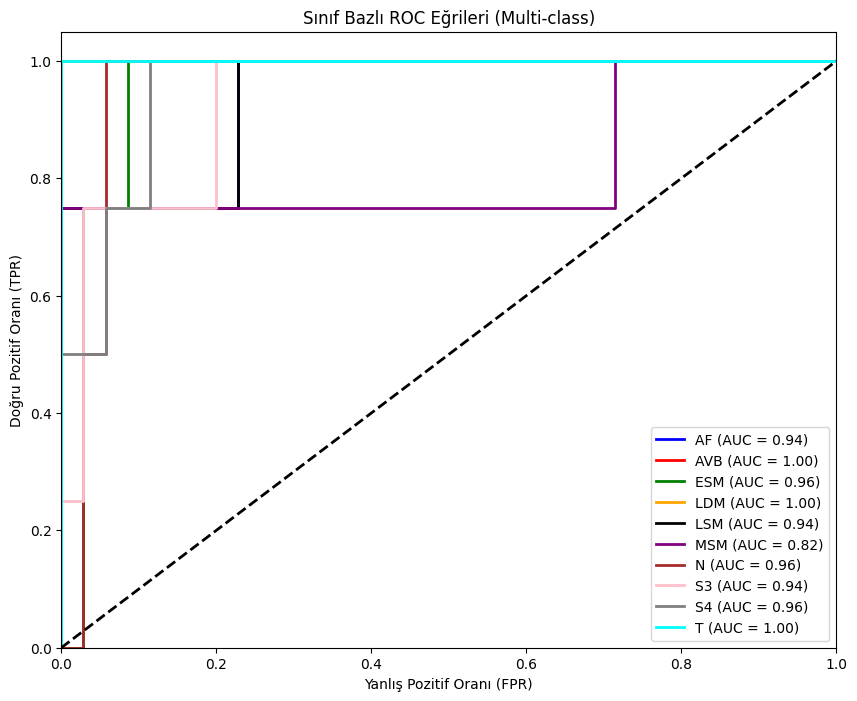


--- Yeni Sınıflandırma Raporu ---
              precision    recall  f1-score   support

          AF       0.75      0.75      0.75         4
         AVB       0.75      1.00      0.86         3
         ESM       0.75      0.75      0.75         4
         LDM       1.00      1.00      1.00         4
         LSM       0.75      0.75      0.75         4
         MSM       1.00      0.75      0.86         4
           N       0.60      0.75      0.67         4
          S3       1.00      0.25      0.40         4
          S4       0.50      0.75      0.60         4
           T       1.00      1.00      1.00         4

    accuracy                           0.77        39
   macro avg       0.81      0.78      0.76        39
weighted avg       0.81      0.77      0.76        39



In [ ]:
# 1. Tahminleri Alalım
y_pred_prob = transfer_model.predict([X_test_audio, X_test_loc])
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

# --- A. Karmaşıklık Matrisi (Confusion Matrix) ---
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le_diag.classes_,
            yticklabels=le_diag.classes_)
plt.title('Final Model: Karmaşıklık Matrisi')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.show()

# --- B. ROC Eğrisi (Sınıf Bazlı) ---
n_classes = len(le_diag.classes_)
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
colors = cycle(['blue', 'red', 'green', 'orange', 'black', 'purple', 'brown', 'pink', 'gray', 'cyan'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{le_diag.classes_[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Yanlış Pozitif Oranı (FPR)')
plt.ylabel('Doğru Pozitif Oranı (TPR)')
plt.title('Sınıf Bazlı ROC Eğrileri (Multi-class)')
plt.legend(loc="lower right")
plt.show()

# --- C. Sınıflandırma Raporu ---
print("\n--- Yeni Sınıflandırma Raporu ---")
print(classification_report(y_true, y_pred, target_names=le_diag.classes_))

Fine-Tuning

In [ ]:
# 1. MobileNetV2 gövdesini eğitilebilir yap
base_model.trainable = True

# 2. Kaç katman olduğunu görelim (MobileNetV2 genellikle 154 katmandır)
print("MobileNetV2 Toplam Katman Sayısı: ", len(base_model.layers))

# 3. Sadece son 30 katmanı eğitime açalım, gerisini donduralım (İlk katmanlar genel şekilleri tanır)
fine_tune_at = 120

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

MobileNetV2 Toplam Katman Sayısı:  156


In [ ]:
# Öğrenme hızını 10 kat daha düşürüyoruz (1e-5)
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Toplam 100 epoch'un üzerine 20-30 epoch daha ekleyelim
fine_tune_epochs = 30
total_epochs =  len(history_tl.epoch) + fine_tune_epochs

history_fine = transfer_model.fit(
    x=[X_train_audio, X_train_loc],
    y=y_train,
    validation_data=([X_test_audio, X_test_loc], y_test),
    epochs=total_epochs,
    initial_epoch=history_tl.epoch[-1], # Önceki eğitimin bittiği yerden başla
    class_weight=class_weights_dict,    # Sınıf ağırlıklarını koruyoruz
    callbacks=[early_stop]
)

Epoch 96/126
5/5 ━━━━━━━━━━━━━━━━━━━━ 29s 3s/step - accuracy: 0.1201 - loss: 13.4179 - val_accuracy: 0.7179 - val_loss: 0.8651
Epoch 97/126
5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.1425 - loss: 11.3196 - val_accuracy: 0.7436 - val_loss: 0.8665
Epoch 98/126
5/5 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.1642 - loss: 9.6334 - val_accuracy: 0.7179 - val_loss: 0.8696
Epoch 99/126
5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.1671 - loss: 8.5269 - val_accuracy: 0.6923 - val_loss: 0.8743
Epoch 100/126
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.1607 - loss: 7.7864 - val_accuracy: 0.6923 - val_loss: 0.8853
Epoch 101/126
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.2146 - loss: 6.8687 - val_accuracy: 0.6667 - val_loss: 0.9039
Epoch 102/126
5/5 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.2318 - loss: 6.1429 - val_accuracy: 0.6923 - val_loss: 0.9382
Epoch 103/126
5/5 ━━━━━━━━━━━━━━━━━━━━ 27s 4s/step - accuracy: 0.3733 - loss: 4.8767 - val_accuracy: 0.6667 - val

# MobileNetV2 Fine-Tuning Sonuçları

In [ ]:
# Modeli test setiyle değerlendir
y_pred_prob = transfer_model.predict([X_test_audio, X_test_loc])
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

# Raporu bas
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, target_names=le_diag.classes_))

1/2 ━━━━━━━━━━━━━━━━━━━━ 5s 6s/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step
              precision    recall  f1-score   support

          AF       0.75      0.75      0.75         4
         AVB       0.75      1.00      0.86         3
         ESM       0.75      0.75      0.75         4
         LDM       1.00      1.00      1.00         4
         LSM       0.75      0.75      0.75         4
         MSM       0.75      0.75      0.75         4
           N       0.60      0.75      0.67         4
          S3       1.00      0.25      0.40         4
          S4       0.60      0.75      0.67         4
           T       1.00      1.00      1.00         4

    accuracy                           0.77        39
   macro avg       0.79      0.78      0.76        39
weighted avg       0.80      0.77      0.76        39



2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 274ms/step


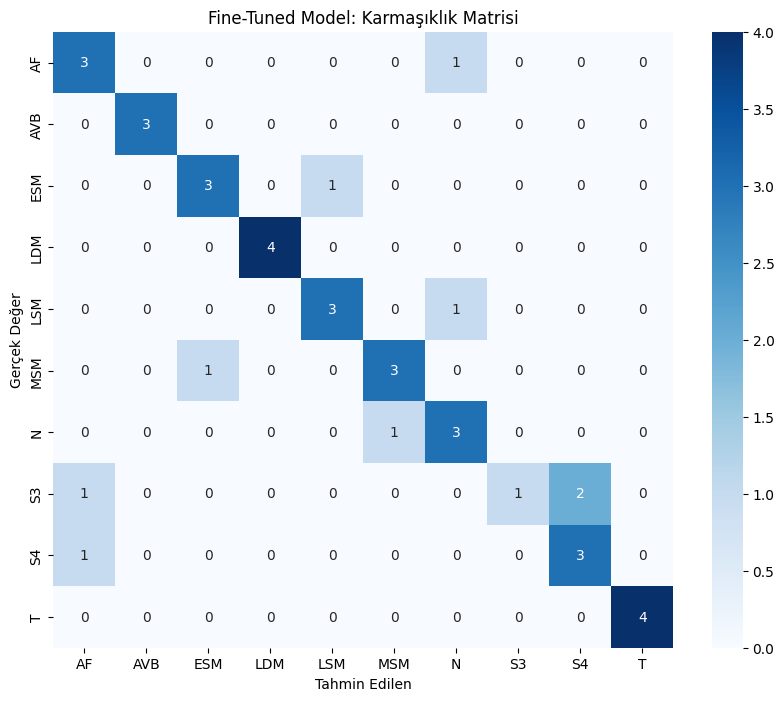

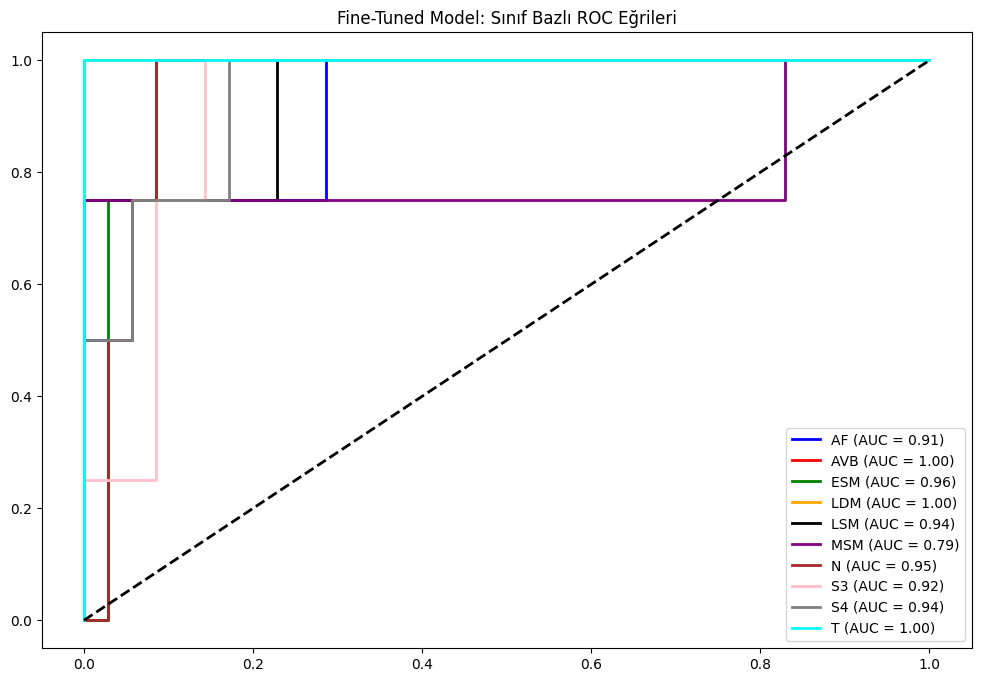

In [ ]:
# Tahmin olasılıklarını al
y_pred_prob = transfer_model.predict([X_test_audio, X_test_loc])
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

# --- A. Karmaşıklık Matrisi ---
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_diag.classes_,
            yticklabels=le_diag.classes_)
plt.title('Fine-Tuned Model: Karmaşıklık Matrisi')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.show()

# --- B. ROC Eğrileri ---
n_classes = len(le_diag.classes_)
fpr = dict(); tpr = dict(); roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(12, 8))
colors = cycle(['blue', 'red', 'green', 'orange', 'black', 'purple', 'brown', 'pink', 'gray', 'cyan'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{le_diag.classes_[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title('Fine-Tuned Model: Sınıf Bazlı ROC Eğrileri')
plt.legend(loc="lower right")
plt.show()

In [ ]:
# 1. Tahminleri al
y_probs_mob = model.predict([X_audio_test, X_loc_test_fixed])
y_preds_mob = np.argmax(y_probs_mob, axis=1)
y_true = np.argmax(y_test, axis=1)

# 2. Hata yapan indeksleri bul
mob_errors = np.where(y_preds_mob != y_true)[0]

print(f"MobileNet Toplam Hata Sayısı: {len(mob_errors)}")
print("-" * 30)

# 3. Detaylı Hata Listesi
for idx in mob_errors:
    print(f"Örnek No: {idx} | Gerçek: {class_names[y_true[idx]]} | Tahmin: {class_names[y_preds_mob[idx]]}")

# 4. Sınıflandırma Raporu
print("\n--- MOBILENET FİNAL RAPORU ---")
print(classification_report(y_true, y_preds_mob, target_names=class_names))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 186ms/step
MobileNet Toplam Hata Sayısı: 12
------------------------------
Örnek No: 6 | Gerçek: S3 | Tahmin: S4
Örnek No: 9 | Gerçek: S3 | Tahmin: N
Örnek No: 11 | Gerçek: S4 | Tahmin: LDM
Örnek No: 14 | Gerçek: ESM | Tahmin: AVB
Örnek No: 15 | Gerçek: LSM | Tahmin: ESM
Örnek No: 16 | Gerçek: AF | Tahmin: N
Örnek No: 17 | Gerçek: LDM | Tahmin: S4
Örnek No: 22 | Gerçek: MSM | Tahmin: ESM
Örnek No: 28 | Gerçek: MSM | Tahmin: ESM
Örnek No: 32 | Gerçek: S4 | Tahmin: LSM
Örnek No: 33 | Gerçek: S3 | Tahmin: LDM
Örnek No: 34 | Gerçek: S3 | Tahmin: N

--- MOBILENET FİNAL RAPORU ---
              precision    recall  f1-score   support

          AF       1.00      0.75      0.86         4
         AVB       0.75      1.00      0.86         3
         ESM       0.50      0.75      0.60         4
         LDM       0.60      0.75      0.67         4
         LSM       0.75      0.75      0.75         4
         MSM       1.00      0.50      0.67         4
           

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Tahmin olasılıklarını al
y_probs = transfer_model.predict([X_audio_test, X_test_loc])
y_preds = np.argmax(y_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# En emin olduğu doğru tahminler
correct_idx = np.where(y_preds == y_true)[0]
top_correct = correct_idx[np.argsort(np.max(y_probs[correct_idx], axis=1))[-3:]]

# En büyük hatalar (Çok emin olup yanlış bildikleri)
wrong_idx = np.where(y_preds != y_true)[0]
top_wrong = wrong_idx[np.argsort(np.max(y_probs[wrong_idx], axis=1))[-3:]]

print("Modelin en çok emin olduğu hatalar (Örnek No):", top_wrong)

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 529ms/step
Modelin en çok emin olduğu hatalar (Örnek No): [15 16 28]


In [ ]:
# 1. Önce tahminleri alalım (Model ismini kendi değişkenine göre güncelle: mobilenet_model vb.)
y_probs = model.predict([X_audio_test, X_loc_test_fixed])
y_preds = np.argmax(y_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# 2. Metrikleri Hesapla
acc = accuracy_score(y_true, y_preds)
balanced_acc = balanced_accuracy_score(y_true, y_preds)

print(f"--- {model.name.upper()} PERFORMANSI ---")
print(f"Genel Doğruluk (Accuracy): %{acc*100:.2f}")
print(f"Dengelenmiş Doğruluk (Balanced Accuracy): %{balanced_acc*100:.2f}")

# 3. Aradaki farkın yorumu
diff = acc - balanced_acc
if diff > 0.10:
    print(f"\n⚠️ UYARI: Aradaki fark (%{diff*100:.2f}) yüksek! \nModel muhtemelen kalabalık sınıfları (Normal gibi) iyi biliyor ama nadir sınıfları (S3 gibi) kaçırıyor.")
else:
    print(f"\n✅ TEBRİKLER: Aradaki fark düşük. \nModelin sınıflar arasında adil bir ayrım yapıyor.")

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 373ms/step
--- FUNCTIONAL_1 PERFORMANSI ---
Genel Doğruluk (Accuracy): %76.92
Dengelenmiş Doğruluk (Balanced Accuracy): %77.50

✅ TEBRİKLER: Aradaki fark düşük. 
Modelin sınıflar arasında adil bir ayrım yapıyor.


In [ ]:
transfer_model.save('kalp_sesi_modeli.h5')

In [ ]:
transfer_model.save('kalp_sesi_modeli.keras')

In [ ]:
model = load_model('kalp_sesi_modeli.keras')

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 45 variables whereas the saved optimizer has 88 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


# Veri Arttırma Deneme, Olumsuz Sonuç

Veri arttırma neden başarısız oldu?
 * Kalp sesleri, kedi-köpek sesi veya sokak gürültüsü gibi "geniş bantlı" sesler değildir. Çok dar frekans aralıklarında (genellikle 20Hz - 500Hz) gerçekleşen çok kısa süreli (milisaniyelik) olaylardır.
 * Kullandığımız MobileNetV2, milyonlarca görüntüyle eğitilmiş devasa bir modeldir. Bizim elimizdeki veri seti (195-468 arası) bu model için çok küçüktür.

In [ ]:
def create_augmented_dataset(X_audio_train, X_loc_train, y_train):
    aug_audio = []
    aug_loc = []
    aug_y = []

    print("Veri artırma işlemi başlatıldı...")

    for i in range(len(X_audio_train)):
        # Mevcut spektrogramı (veya orijinal sesi) al
        original_spec = X_audio_train[i]
        loc = X_loc_train[i]
        label = y_train[i]

        # 1. Orijinali ekle
        aug_audio.append(original_spec)
        aug_loc.append(loc)
        aug_y.append(label)

        # 2. Spektrogram seviyesinde gürültü ekleme (Hafif Gauss Gürültüsü)
        noise = np.random.normal(0, 0.02, original_spec.shape)
        noisy_spec = original_spec + noise
        aug_audio.append(noisy_spec)
        aug_loc.append(loc)
        aug_y.append(label)

        # 3. Zaman Kaydırma (Time Shifting)
        # Spektrogramı yatay eksende rastgele %10 kaydırır
        shift = np.random.randint(5, 20)
        shifted_spec = np.roll(original_spec, shift, axis=1)
        aug_audio.append(shifted_spec)
        aug_loc.append(loc)
        aug_y.append(label)

    return np.array(aug_audio), np.array(aug_loc), np.array(aug_y)

# Veriyi çoğaltalım (Eğitim setini 3 katına çıkarıyoruz)
X_train_audio_aug, X_train_loc_aug, y_train_aug = create_augmented_dataset(X_train_audio, X_train_loc, y_train)

print(f"Yeni Eğitim Seti Boyutu: {len(X_train_audio_aug)}")

Veri artırma işlemi başlatıldı...
Yeni Eğitim Seti Boyutu: 468


In [ ]:
# Modeli düşük bir öğrenme hızıyla tekrar derliyoruz
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Erken durdurma kriterini güncelliyoruz
early_stop_aug = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

print("Artırılmış veri ile final eğitimi başlıyor...")

history_aug = transfer_model.fit(
    x=[X_train_audio_aug, X_train_loc_aug],
    y=y_train_aug,
    validation_data=([X_test_audio, X_test_loc], y_test), # Test seti orijinal kalmalı
    epochs=50,
    batch_size=16,
    class_weight=class_weights_dict,
    callbacks=[early_stop_aug]
)

Artırılmış veri ile final eğitimi başlıyor...
Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.1118 - loss: 12.3921 - val_accuracy: 0.7692 - val_loss: 0.8905
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.2186 - loss: 7.0567 - val_accuracy: 0.5897 - val_loss: 1.2206
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.3003 - loss: 3.8717 - val_accuracy: 0.5128 - val_loss: 1.8900
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 30s 994ms/step - accuracy: 0.4209 - loss: 2.6307 - val_accuracy: 0.4615 - val_loss: 2.6526
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 29s 986ms/step - accuracy: 0.5315 - loss: 1.7282 - val_accuracy: 0.4103 - val_loss: 3.0248
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 29s 987ms/step - accuracy: 0.5934 - loss: 1.2771 - val_accuracy: 0.4103 - val_loss: 3.2678
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 41s 987ms/step - accuracy: 0.6877 - loss: 1.0257 - val_accuracy: 0.3846 - val_loss: 3.4533
Epoch 8/50
29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 955ms/step - accur

KeyboardInterrupt: 

In [ ]:
from imblearn.over_sampling import SMOTE

# 1. Kaydettiğin dosyaları geri yükle (Dosya isimlerinle birebir aynı)
X_audio_train = np.load('X_audio_train.npy')
X_audio_test = np.load('X_audio_test.npy')
X_loc_train = np.load('X_loc_train.npy')
X_loc_test = np.load('X_loc_test.npy')
y_train = np.load('y_train.npy')
y_test = np.load('y_test.npy')

print(f"Veriler yüklendi. Orijinal Eğitim Seti: {X_audio_train.shape[0]} örnek")

# 2. SMOTE Hazırlığı (Düzleştirme)
n_samples, h, w, c = X_audio_train.shape
X_train_flat = X_audio_train.reshape(n_samples, h * w * c)

# 3. SMOTE Uygula
sm = SMOTE(random_state=42, k_neighbors=3)
y_train_indices = np.argmax(y_train, axis=1) # One-hot'tan sayıya
X_resampled_flat, y_resampled_indices = sm.fit_resample(X_train_flat, y_train_indices)

# 4. Boyutları Geri Yükle
X_train_smote = X_resampled_flat.reshape(-1, h, w, c)
y_train_smote = tf.keras.utils.to_categorical(y_resampled_indices, num_classes=10)

# 5. Lokasyon Verilerini Senkronize Et
X_loc_train_smote = []
for label_idx in y_resampled_indices:
    mask = (y_train_indices == label_idx)
    possible_locs = X_loc_train[mask]
    X_loc_train_smote.append(possible_locs[np.random.randint(0, len(possible_locs))])
X_loc_train_smote = np.array(X_loc_train_smote)

print(f"SMOTE Başarılı! Yeni Eğitim Seti: {X_train_smote.shape[0]} örnek")

Veriler yüklendi. Orijinal Eğitim Seti: 156 örnek
SMOTE Başarılı! Yeni Eğitim Seti: 180 örnek


In [ ]:
# 1. Modeli yükle
transfer_model = load_model('kalp_sesi_modeli.keras')

# 2. İnce Ayar (Fine-Tuning) hazırlığı
# Modelin içindeki MobileNetV2 katmanlarını bulup son kısımlarını eğitime açalım
for layer in transfer_model.layers:
    if layer.name == 'mobilenetv2_1.00_224': # Modelindeki MobileNet katmanının adı
        layer.trainable = True
        # Sadece son 20 katmanı açarak modelin temel özelliklerini bozmayalım
        for sub_layer in layer.layers[:-20]:
            sub_layer.trainable = False

# 3. Modeli çok düşük bir learning rate ile tekrar derle
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Erken Durdurma (Early Stopping) tanımla
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

print("İnce ayar + SMOTE dengeli eğitimi başlıyor...")

# 5. EĞİTİM
history_smote_finetuned = transfer_model.fit(
    x=[X_train_smote, X_loc_train_smote],
    y=y_train_smote,
    validation_data=([X_audio_test, X_loc_test], y_test),
    epochs=50,
    batch_size=16,
    callbacks=[early_stop]
)

İnce ayar + SMOTE dengeli eğitimi başlıyor...
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 45 variables whereas the saved optimizer has 88 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


12/12 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.1187 - loss: 13.8063 - val_accuracy: 0.7179 - val_loss: 0.9137
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.1845 - loss: 10.7689 - val_accuracy: 0.7179 - val_loss: 0.9298
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 994ms/step - accuracy: 0.2270 - loss: 8.1803 - val_accuracy: 0.7179 - val_loss: 0.9651
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 931ms/step - accuracy: 0.2856 - loss: 5.7712 - val_accuracy: 0.6410 - val_loss: 1.0822
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.3271 - loss: 4.4827 - val_accuracy: 0.5897 - val_loss: 1.2964
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.2803 - loss: 4.1783 - val_accuracy: 0.5641 - val_loss: 1.6842
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.4011 - loss: 2.7375 - val_accuracy: 0.5128 - val_loss: 2.1459
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.4340 - loss: 2.6332 - val_accuracy: 0.5128 - val_loss: 2.

# Resnet50

ResNet50

In [ ]:
from tensorflow.keras.applications import ResNet50

# MobileNetV2 yerine ResNet50 yüklüyoruz
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Geri kalan katman birleştirme (Audio + Location) mantığı aynı kalacak

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# 1. Kaydettiğin dosyaları geri yükle (Dosya isimlerinle birebir aynı)
X_audio_train = np.load('X_audio_train.npy')
X_audio_test = np.load('X_audio_test.npy')
X_loc_train = np.load('X_loc_train.npy')
X_loc_test = np.load('X_loc_test.npy')
y_train = np.load('y_train.npy')
y_test = np.load('y_test.npy')

In [ ]:
# Veri Yapısı Kontrol Paneli
print("--- Veri Seti Detayları ---")
variables = {
    "Ses Eğitim (X_audio_train)": X_audio_train,
    "Ses Test (X_audio_test)": X_audio_test,
    "Konum Eğitim (X_loc_train)": X_loc_train,
    "Konum Test (X_loc_test)": X_loc_test,
    "Etiket Eğitim (y_train)": y_train,
    "Etiket Test (y_test)": y_test
}

for name, var in variables.items():
    print(f"{name:25} | Şekil (Shape): {var.shape} | Tip: {var.dtype}")

# Örnek bir lokasyon verisi içeriği
print("\n--- İçerik Analizi ---")
print(f"İlk 5 Lokasyon Verisi:\n{X_loc_train[:5]}")
print(f"İlk 5 Etiket (One-Hot):\n{y_train[:5]}")

--- Veri Seti Detayları ---
Ses Eğitim (X_audio_train) | Şekil (Shape): (156, 40, 646, 1) | Tip: float32
Ses Test (X_audio_test)   | Şekil (Shape): (39, 40, 646, 1) | Tip: float32
Konum Eğitim (X_loc_train) | Şekil (Shape): (156,) | Tip: int64
Konum Test (X_loc_test)   | Şekil (Shape): (39,) | Tip: int64
Etiket Eğitim (y_train)   | Şekil (Shape): (156, 10) | Tip: float64
Etiket Test (y_test)      | Şekil (Shape): (39, 10) | Tip: float64

--- İçerik Analizi ---
İlk 5 Lokasyon Verisi:
[11  6 11  6  2]
İlk 5 Etiket (One-Hot):
[[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]]


In [ ]:
# 1. Eğitim setindeki sayısal etiketleri al (One-hot olmayan hali)
y_train_integers = np.argmax(y_train, axis=1)

# 2. Sınıf ağırlıklarını 'balanced' (dengeli) modda hesapla
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_integers),
    y=y_train_integers
)

# 3. Keras'ın anlayacağı sözlük formatına çevir
class_weights_dict = dict(enumerate(weights))

print("Hesaplanan Sınıf Ağırlıkları:", class_weights_dict)

Hesaplanan Sınıf Ağırlıkları: {0: np.float64(1.04), 1: np.float64(1.2), 2: np.float64(1.04), 3: np.float64(1.04), 4: np.float64(0.8666666666666667), 5: np.float64(0.9176470588235294), 6: np.float64(0.8666666666666667), 7: np.float64(0.975), 8: np.float64(1.1142857142857143), 9: np.float64(1.04)}


In [ ]:
# 1. Lokasyon verisini 2 boyutlu hale getir (Hata çözümü)
X_loc_train_fixed = X_loc_train.reshape(-1, 1).astype('float32')
X_loc_test_fixed = X_loc_test.reshape(-1, 1).astype('float32')

# 2. ResNet50 Modeli (Senin boyutlarına uyarlanmış)
input_audio = Input(shape=(40, 646, 1), name='audio_input')

# ResNet 3 kanal beklediği için veriyi 3 kanala çoğaltıyoruz
x = tf.keras.layers.Concatenate()([input_audio, input_audio, input_audio])

# ResNet'in beklediği boyuta (224, 224) otomatik resize yapalım
x = Resizing(224, 224)(x)

base_model_resnet = tf.keras.applications.ResNet50(
    weights='imagenet',
    include_top=False,
    input_tensor=x
)
base_model_resnet.trainable = False # Önce donduruyoruz

x_audio = GlobalAveragePooling2D()(base_model_resnet.output)
x_audio = Dense(256, activation='relu')(x_audio)
x_audio = Dropout(0.4)(x_audio)

# 3. Lokasyon Girişi (Artık matris formunda)
input_loc = Input(shape=(1,), name='loc_input')
x_loc = Dense(16, activation='relu')(input_loc)

# 4. Birleştirme
combined = Concatenate()([x_audio, x_loc])
x = Dense(128, activation='relu')(combined)
output = Dense(10, activation='softmax')(x)

# 5. Modeli Derle
resnet_model = Model(inputs=[input_audio, input_loc], outputs=output)
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("ResNet50 Modeli senin verilerine göre inşa edildi!")

ResNet50 Modeli senin verilerine göre inşa edildi!


In [ ]:
history_resnet = resnet_model.fit(
    x=[X_audio_train, X_loc_train_fixed],
    y=y_train,
    validation_data=([X_audio_test, X_loc_test_fixed], y_test),
    epochs=30,
    batch_size=16,
    class_weight=class_weights_dict # S3 gibi az sınıflar için hala önemli
)

Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 50s 4s/step - accuracy: 0.0855 - loss: 2.6157 - val_accuracy: 0.1538 - val_loss: 2.2336
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 35s 4s/step - accuracy: 0.1137 - loss: 2.3221 - val_accuracy: 0.3333 - val_loss: 2.0609
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 34s 4s/step - accuracy: 0.2319 - loss: 2.0178 - val_accuracy: 0.4359 - val_loss: 1.9407
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 44s 4s/step - accuracy: 0.3440 - loss: 1.9659 - val_accuracy: 0.4872 - val_loss: 1.8410
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 37s 4s/step - accuracy: 0.4066 - loss: 1.7947 - val_accuracy: 0.5385 - val_loss: 1.7424
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 41s 4s/step - accuracy: 0.4097 - loss: 1.6926 - val_accuracy: 0.5641 - val_loss: 1.6541
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 38s 4s/step - accuracy: 0.5414 - loss: 1.5969 - val_accuracy: 0.4872 - val_loss: 1.5802
Epoch 8/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 45s 4s/step - accuracy: 0.6460 - loss: 1.3254 - val_accuracy: 0.6154 - val_loss:

2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step

🧬 RESNET50 MODEL PERFORMANS RAPORU
📊 Genel Test Doğruluğu (Accuracy):      %79.49
⚖️  Dengelenmiş Doğruluk (Balanced Acc): %80.00
🧬 RESNET50 MODEL PERFORMANS RAPORU
              precision    recall  f1-score   support

          AF       0.80      1.00      0.89         4
         AVB       1.00      1.00      1.00         3
         ESM       0.75      0.75      0.75         4
         LDM       1.00      0.75      0.86         4
         LSM       1.00      0.75      0.86         4
         MSM       0.50      0.75      0.60         4
           N       1.00      0.50      0.67         4
          S3       0.67      0.50      0.57         4
          S4       0.67      1.00      0.80         4
           T       1.00      1.00      1.00         4

    accuracy                           0.79        39
   macro avg       0.84      0.80      0.80        39
weighted avg       0.83      0.79      0.79        39



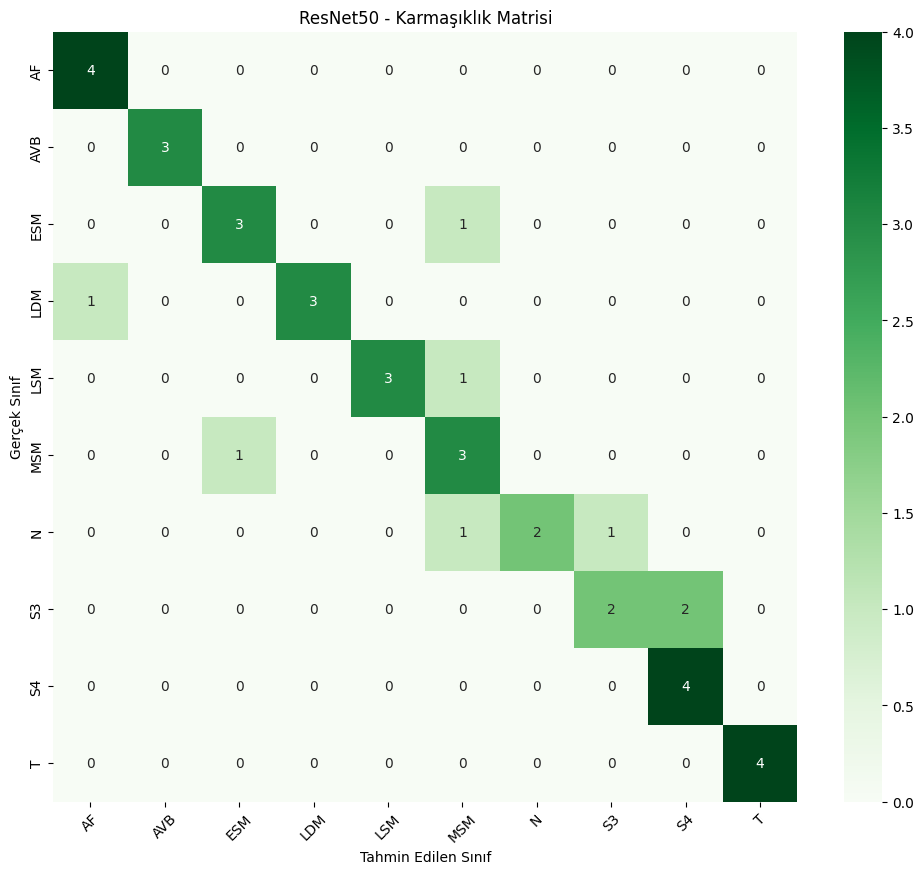

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, balanced_accuracy_score, confusion_matrix

# 1. Tahminleri Al
# Not: Eğer model ismin 'resnet_model' ise aşağıyı ona göre güncelle
y_pred_probs_res = resnet_model.predict([X_audio_test, X_loc_test_fixed])
y_pred_res = np.argmax(y_pred_probs_res, axis=1)
y_true = np.argmax(y_test, axis=1)

# 2. Temel Başarı Metriklerini Hesapla
genel_acc_res = accuracy_score(y_true, y_pred_res)
balanced_acc_res = balanced_accuracy_score(y_true, y_pred_res)

print("\n" + "="*60)
print("🧬 RESNET50 MODEL PERFORMANS RAPORU")
print("="*60)
print(f"📊 Genel Test Doğruluğu (Accuracy):      %{genel_acc_res*100:.2f}")
print(f"⚖️  Dengelenmiş Doğruluk (Balanced Acc): %{balanced_acc_res*100:.2f}")
print("="*60)

# 3. Detaylı Sınıflandırma Raporu (Hastalık Bazında)
print("🧬 RESNET50 MODEL PERFORMANS RAPORU")
print(classification_report(y_true, y_pred_res, target_names=le_diag.classes_))

# 4. Karmaşıklık Matrisi (Confusion Matrix) Görselleştirme
cm_res = confusion_matrix(y_true, y_pred_res)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_res, annot=True, fmt='d', cmap='Greens', # ResNet için Yeşil tonu seçtim (MobileNet'ten farklı olsun)
            xticklabels=le_diag.classes_, yticklabels=le_diag.classes_)
plt.title('ResNet50 - Karmaşıklık Matrisi')
plt.xlabel('Tahmin Edilen Sınıf')
plt.ylabel('Gerçek Sınıf')
plt.xticks(rotation=45)
plt.show()

In [ ]:
import os

# 1. Modeller için klasör yolunu belirle
base_path = "/content/drive/My Drive/Colab Notebooks/heart sound/"
model_path = os.path.join(base_path, "models/")

# 2. Klasörü oluştur (yoksa)
os.makedirs(model_path, exist_ok=True)

# 3. ResNet50 modelini kaydet
resnet_model.save(model_path + 'kalp_sesi_resnet50_final.keras')
print(f"✅ ResNet50 modeli kaydedildi: {model_path}kalp_sesi_resnet50_final.keras")

# 4. MobileNetV2 modelini kaydet
transfer_model.save(model_path + 'kalp_sesi_mobilenet_final.keras')
print(f"✅ MobileNetV2 modeli kaydedildi: {model_path}kalp_sesi_mobilenet_final.keras")

✅ ResNet50 modeli kaydedildi: /content/drive/My Drive/Colab Notebooks/heart sound/models/kalp_sesi_resnet50_final.keras
✅ MobileNetV2 modeli kaydedildi: /content/drive/My Drive/Colab Notebooks/heart sound/models/kalp_sesi_mobilenet_final.keras


In [ ]:
# Tahminleri al
y_pred = resnet_model.predict([X_audio_test, X_loc_test_fixed])
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Sonuçları yazdır
print(f"Genel Doğruluk: %{accuracy_score(y_true, y_pred_classes)*100:.2f}")
print(f"Dengelenmiş Doğruluk: %{balanced_accuracy_score(y_true, y_pred_classes)*100:.2f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step
Genel Doğruluk: %79.49
Dengelenmiş Doğruluk: %80.00


In [ ]:
# Yanlış tahmin edilenlerin indekslerini bul
errors = np.where(y_pred_classes != y_true)[0]

print(f"Toplam hata sayısı: {len(errors)}")
for i in errors[:12]: # İlk 5 hatayı göster
    print(f"Örnek No: {i} | Gerçek: {class_names[y_true[i]]} | Tahmin: {class_names[y_pred_classes[i]]}")

Toplam hata sayısı: 8
Örnek No: 9 | Gerçek: S3 | Tahmin: S4
Örnek No: 10 | Gerçek: N | Tahmin: MSM
Örnek No: 14 | Gerçek: ESM | Tahmin: MSM
Örnek No: 15 | Gerçek: LSM | Tahmin: MSM
Örnek No: 17 | Gerçek: LDM | Tahmin: AF
Örnek No: 21 | Gerçek: N | Tahmin: S3
Örnek No: 28 | Gerçek: MSM | Tahmin: ESM
Örnek No: 34 | Gerçek: S3 | Tahmin: S4


In [ ]:
# ResNet modelini farklı bir isimle kaydediyoruz
resnet_model.save('kalp_sesi_resnet50_final.keras')

print("ResNet50 modeli 'kalp_sesi_resnet50_final.keras' adıyla kaydedildi.")


ResNet50 modeli 'kalp_sesi_resnet50_final.keras' adıyla kaydedildi.


In [ ]:
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score

# 1. Modelleri Drive'dan Yükle
path = "/content/drive/My Drive/Colab Notebooks/heart sound/models/"
model_mob = load_model(path + 'kalp_sesi_mobilenet_final.keras')
model_res = load_model(path + 'kalp_sesi_resnet50_final.keras')

# 2. Tahminleri Al
probs_mob = model_mob.predict([X_audio_test, X_loc_test_fixed])
probs_res = model_res.predict([X_audio_test, X_loc_test_fixed])

# 3. Ensemble (Soft Voting) - Olasılıkları Harmanla
ensemble_probs = (probs_mob + probs_res) / 2
ensemble_preds = np.argmax(ensemble_probs, axis=1)

# 4. Final Başarıyı Ölç
y_true = np.argmax(y_test, axis=1)
print(f"Final Ensemble Doğruluğu: %{accuracy_score(y_true, ensemble_preds)*100:.2f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step
Final Ensemble Doğruluğu: %79.49


In [ ]:
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, balanced_accuracy_score

# 1. Modelleri Yükle
path = "/content/drive/My Drive/Colab Notebooks/heart sound/models/"
model_mob = load_model(path + 'kalp_sesi_mobilenet_final.keras')
model_res = load_model(path + 'kalp_sesi_resnet50_final.keras')

# 2. Tahmin Olasılıkları
probs_mob = model_mob.predict([X_audio_test, X_loc_test_fixed])
probs_res = model_res.predict([X_audio_test, X_loc_test_fixed])

# 3. Ensemble (Soft Voting)
ensemble_probs = (probs_mob + probs_res) / 2
ensemble_preds = np.argmax(ensemble_probs, axis=1)

# 4. Gerçek Etiketler
y_true = np.argmax(y_test, axis=1)

# 5. Metrikler
acc = accuracy_score(y_true, ensemble_preds)
bal_acc = balanced_accuracy_score(y_true, ensemble_preds)

# 6. Raporlama
print("========== ENSEMBLE MODEL PERFORMANSI ==========")
print(f"Genel Doğruluk (Accuracy):        %{acc*100:.2f}")
print(f"Dengelenmiş Doğruluk (Balanced): %{bal_acc*100:.2f}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step
========== ENSEMBLE MODEL PERFORMANSI ==========
Genel Doğruluk (Accuracy):        %79.49
Dengelenmiş Doğruluk (Balanced): %80.00



★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
🏆 FINAL ENSEMBLE MODEL (MOBILENET + RESNET) SONUÇLARI
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
📊 Final Ensemble Genel Doğruluk (Accuracy):      %79.49
⚖️  Final Ensemble Dengelenmiş Doğruluk (Balanced): %80.00
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★

📋 Final Ensemble Rapor (Precision, Recall, F1):

              precision    recall  f1-score   support

          AF       1.00      0.75      0.86         4
         AVB       1.00      1.00      1.00         3
         ESM       0.80      1.00      0.89         4
         LDM       1.00      1.00      1.00         4
         LSM       1.00      0.75      0.86         4
         MSM       0.60      0.75      0.67         4
           N       0.67      0.50      0.57         4
          S3       0.50      0.25      0.33         4
          S4       0.57      1.00      0.73         4
           T       1.00      1.00      1.00         4

 

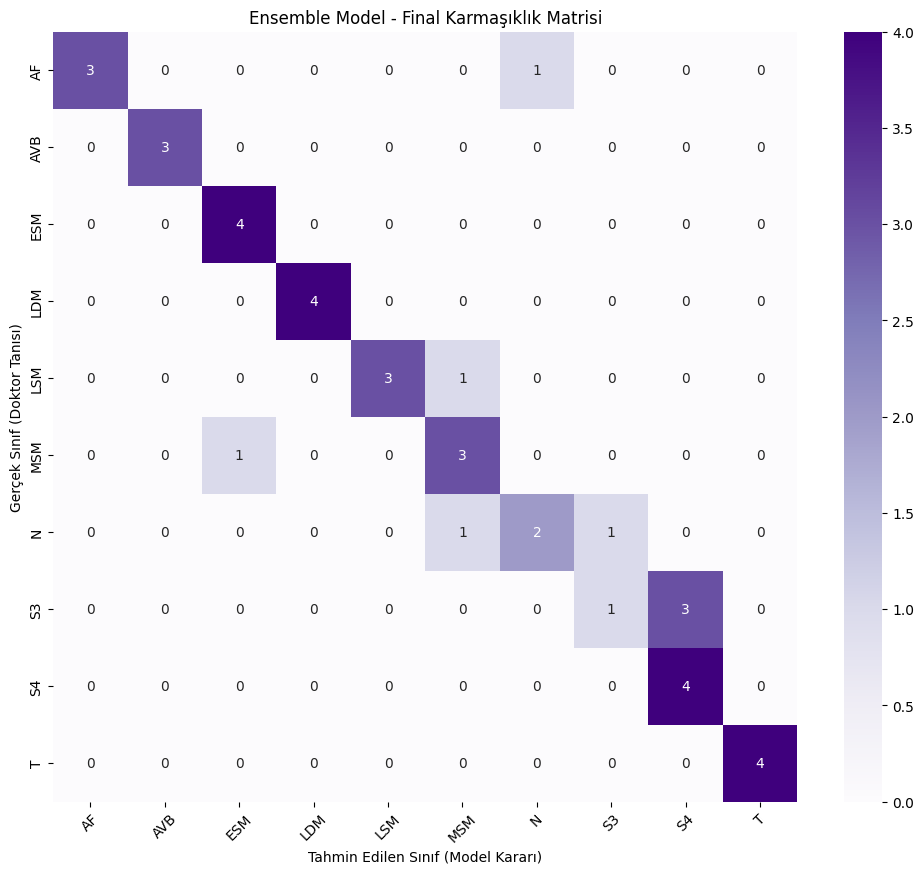

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, balanced_accuracy_score, confusion_matrix

# 1. Tahminleri ve Olasılıkları Zaten Aldın (ensemble_preds ve ensemble_probs hazır)
y_true = np.argmax(y_test, axis=1)

# 2. Final Metrikleri Hesapla
final_genel_acc = accuracy_score(y_true, ensemble_preds)
final_balanced_acc = balanced_accuracy_score(y_true, ensemble_preds)

print("\n" + "★"*60)
print("🏆 FINAL ENSEMBLE MODEL (MOBILENET + RESNET) SONUÇLARI")
print("★"*60)
print(f"📊 Final Ensemble Genel Doğruluk (Accuracy):      %{final_genel_acc*100:.2f}")
print(f"⚖️  Final Ensemble Dengelenmiş Doğruluk (Balanced): %{final_balanced_acc*100:.2f}")
print("★"*60)

# 3. Detaylı Sınıflandırma Raporu
# Sınıf isimlerini le_diag üzerinden alıyoruz
class_names = list(le_diag.classes_)
print("\n📋 Final Ensemble Rapor (Precision, Recall, F1):\n")
print(classification_report(y_true, ensemble_preds, target_names=class_names))

# 4. Final Karmaşıklık Matrisi
cm_ens = confusion_matrix(y_true, ensemble_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_ens, annot=True, fmt='d', cmap='Purples', # Ensemble için asil bir mor tonu
            xticklabels=class_names, yticklabels=class_names)
plt.title('Ensemble Model - Final Karmaşıklık Matrisi')
plt.xlabel('Tahmin Edilen Sınıf (Model Kararı)')
plt.ylabel('Gerçek Sınıf (Doktor Tanısı)')
plt.xticks(rotation=45)
plt.show()

/tmp/ipython-input-3906451672.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('jet')(np.linspace(0, 1, n_classes))


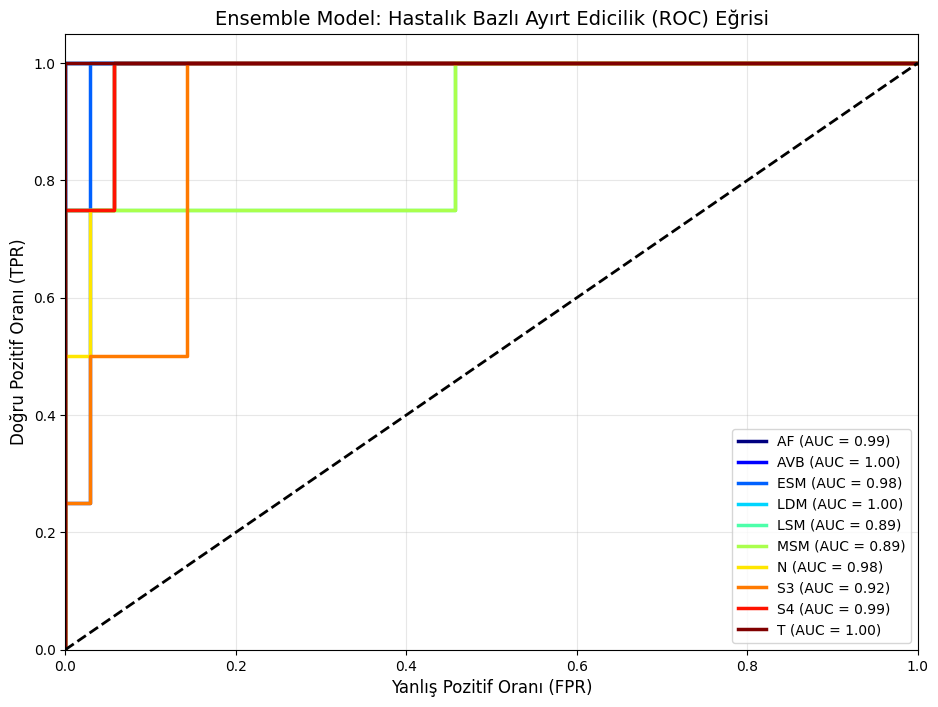

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# 1. Sınıfları ikilik sisteme dönüştür
y_test_bin = label_binarize(y_true, classes=range(len(class_names)))
n_classes = len(class_names)

# 2. Her sınıf için ROC ve AUC hesapla
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    # ensemble_probs değişkenini önceki kodda hesaplamıştık
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], ensemble_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 3. Grafiği Çiz
plt.figure(figsize=(11, 8))
colors = plt.cm.get_cmap('jet')(np.linspace(0, 1, n_classes))

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2.5,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2) # Şans çizgisi
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Yanlış Pozitif Oranı (FPR)', fontsize=12)
plt.ylabel('Doğru Pozitif Oranı (TPR)', fontsize=12)
plt.title('Ensemble Model: Hastalık Bazlı Ayırt Edicilik (ROC) Eğrisi', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.show()

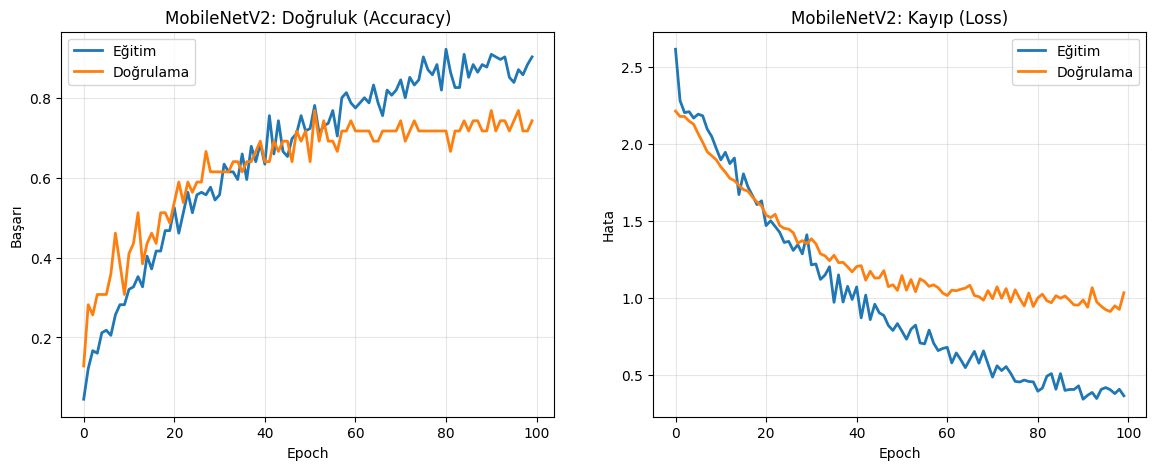

In [ ]:
def plot_learning_curves(history, model_name):
    plt.figure(figsize=(14, 5))

    # Accuracy Grafiği
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Eğitim', lw=2)
    plt.plot(history.history['val_accuracy'], label='Doğrulama', lw=2)
    plt.title(f'{model_name}: Doğruluk (Accuracy)')
    plt.xlabel('Epoch')
    plt.ylabel('Başarı')
    plt.legend()
    plt.grid(alpha=0.3)

    # Loss Grafiği
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Eğitim', lw=2)
    plt.plot(history.history['val_loss'], label='Doğrulama', lw=2)
    plt.title(f'{model_name}: Kayıp (Loss)')
    plt.xlabel('Epoch')
    plt.ylabel('Hata')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# Her iki model için çağır (history_tl ve history_res senin değişken isimlerin olmalı)
plot_learning_curves(history_tl, "MobileNetV2")
# plot_learning_curves(history_res, "ResNet50") # Eğer ResNet history'si hafızadaysa çalıştır

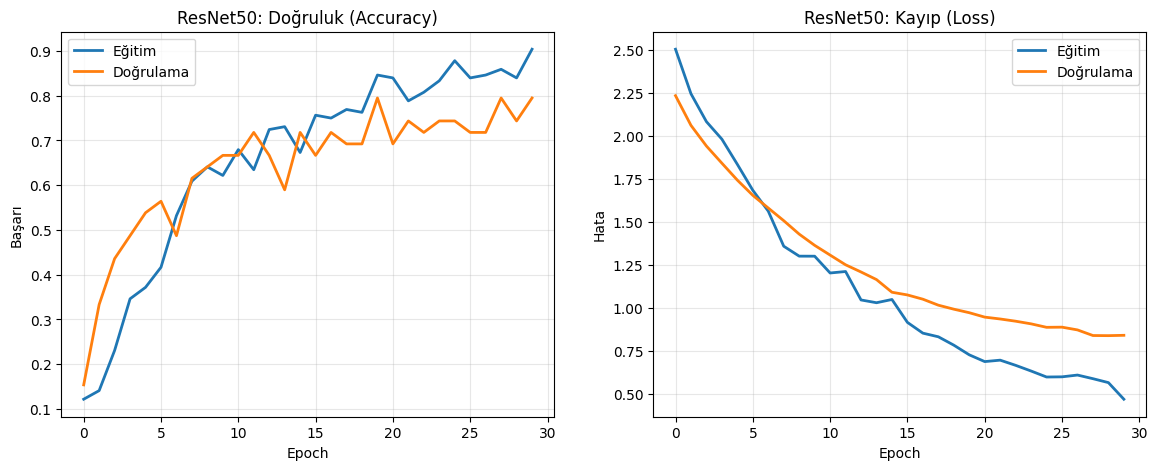

In [ ]:
def plot_learning_curves(history, model_name):
    plt.figure(figsize=(14, 5))

    # Accuracy Grafiği
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Eğitim', lw=2)
    plt.plot(history.history['val_accuracy'], label='Doğrulama', lw=2)
    plt.title(f'{model_name}: Doğruluk (Accuracy)')
    plt.xlabel('Epoch')
    plt.ylabel('Başarı')
    plt.legend()
    plt.grid(alpha=0.3)

    # Loss Grafiği
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Eğitim', lw=2)
    plt.plot(history.history['val_loss'], label='Doğrulama', lw=2)
    plt.title(f'{model_name}: Kayıp (Loss)')
    plt.xlabel('Epoch')
    plt.ylabel('Hata')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# Her iki model için çağır (history_tl ve history_res senin değişken isimlerin olmalı)
plot_learning_curves(history_resnet, "ResNet50")
# plot_learning_curves(history_res, "ResNet50") # Eğer ResNet history'si hafızadaysa çalıştır

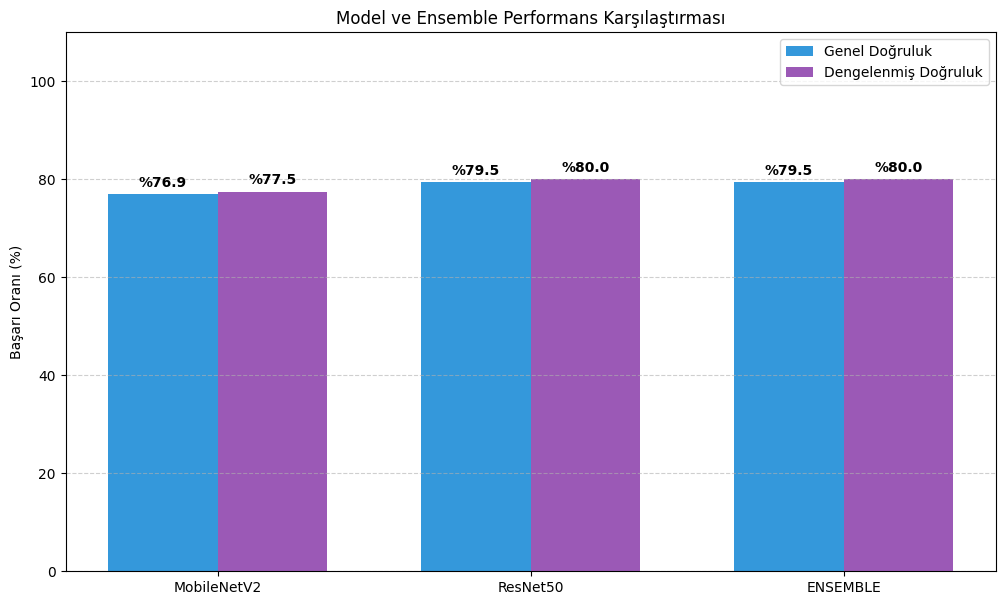

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Not: genel_acc (MobileNet) ve genel_acc_res (ResNet) değerlerinin
# daha önceden hesaplanmış olması gerekir.
models = ['MobileNetV2', 'ResNet50', 'ENSEMBLE']
acc_values = [genel_acc * 100, genel_acc_res * 100, final_genel_acc * 100]
balanced_values = [balanced_acc * 100, balanced_acc_res * 100, final_balanced_acc * 100]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))
rects1 = ax.bar(x - width/2, acc_values, width, label='Genel Doğruluk', color='#3498db')
rects2 = ax.bar(x + width/2, balanced_values, width, label='Dengelenmiş Doğruluk', color='#9b59b6')

ax.set_ylabel('Başarı Oranı (%)')
ax.set_title('Model ve Ensemble Performans Karşılaştırması')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, 110)

# Değerleri barların üzerine yazdır
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'%{height:.1f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()